Cargando datos...


[*********************100%***********************]  23 of 23 completed


Datos cargados: 16191 días, 23 activos
Rango: 1962-01-03 → 2026-05-04
Ventana entrada=10, salida=90
  X_train: (14482, 10, 23) | y_train: (14482, 23)
  X_test:  (1610, 10, 23)  | y_test:  (1610, 23)
X_train: (14482, 10, 23)  y_train: (14482, 23)
X_test:  (1610, 10, 23)   y_test:  (1610, 23)
Train:   (13033, 10, 23)  Val: (1449, 10, 23)

  Modelo: CNN_LSTM_cf32_64_lstm64_in10_out90
  Parámetros: 50,135


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 10, 23)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 10, 32)         │         3,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 10, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 10, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 10, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,327 (196.59 KB)

 Trainable params: 50,135 (195.84 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/300
408/408 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0133 - val_loss: 0.0067
Epoch 2/300
408/408 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0061 - val_loss: 0.0048
Epoch 3/300
408/408 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0043 - val_loss: 0.0032
Epoch 4/300
408/408 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0030 - val_loss: 0.0021
Epoch 5/300
408/408 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0021 - val_loss: 0.0015
Epoch 6/300
408/408 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0016 - val_loss: 0.0012
Epoch 7/300
408/408 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0014 - val_loss: 0.0010
Epoch 8/300
408/408 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0013 - val_loss: 9.6550e-04
Epoch 9/300
408/408 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0013 - val_loss: 9.4940e-04
Epoch 10/300
408/408 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0013 - val_loss: 9.4696e-04
Epoch 11/300
408/408 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0013 - val_loss: 9.4797e-04
Epoch 12/300
408/408 ━━━━

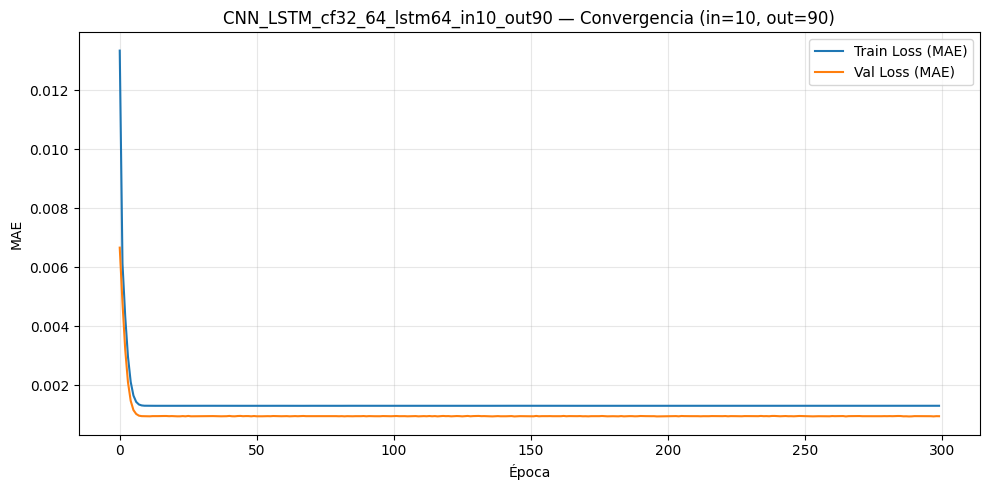

Modelo guardado en: models/CNN_LSTM_cf32_64_lstm64_in10_out90.keras


In [1]:
"""
cnn_lstm_model.py — Modelo híbrido CNN + LSTM
==============================================================================

Arquitectura:
  Conv1D → (Conv1D) → LSTM → Dense → salida

Las capas convolucionales extraen patrones locales (momentum, spikes, reversiones)
y la LSTM procesa la secuencia de esos patrones para capturar dependencias
temporales de más largo plazo.

Cambia los parámetros en la sección CONFIGURACIÓN y ejecuta.
"""
import os
import sys
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Apuntar a la raíz del repositorio ──
os.chdir(r'C:\Users\eneko\neural-network-forecasting')
sys.path.insert(0, os.getcwd())

# ── Imports del repositorio ──
from config import RANDOM_SEED, MODELS_DIR, FIGURES_DIR
from src.data_pipeline import load_data, get_train_test
from src.evaluation import compute_mae, save_results, count_parameters
from src.plotting import plot_training_curves

np.random.seed(RANDOM_SEED)
import tensorflow as tf
tf.random.set_seed(RANDOM_SEED)

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, LSTM, Dense, Dropout,
    BatchNormalization, GlobalAveragePooling1D, SpatialDropout1D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)


# ============================================================================
# ▶▶▶ CONFIGURACIÓN — CAMBIA AQUÍ LOS PARÁMETROS ◀◀◀
# ============================================================================

# --- Ventanas ---
INPUT_WINDOW  = 10
OUTPUT_WINDOW = 90

# --- Bloque convolucional ---
FILTERS_1     = 32          # Filtros primera Conv1D
KERNEL_SIZE_1 = 5           # Kernel primera Conv1D
FILTERS_2     = 64          # Filtros segunda Conv1D (0 para desactivar)
KERNEL_SIZE_2 = 3           # Kernel segunda Conv1D
PADDING       = 'same'      # Siempre 'same' para mantener resolución temporal
SPATIAL_DROP  = 0.0         # SpatialDropout1D tras cada conv (0 para desactivar)
USE_BATCHNORM = True        # BatchNormalization tras cada conv
L2_REG        = 0.0001      # Regularización L2 en capas conv (0 para desactivar)

# --- Bloque LSTM ---
LSTM_UNITS_1  = 64          # Unidades primera LSTM
LSTM_UNITS_2  = 0           # Unidades segunda LSTM (0 para desactivar)
LSTM_DROPOUT  = 0.1         # Dropout interno de la LSTM (recurrent_dropout)
LSTM_USE_GAP  = False       # True → GlobalAveragePooling sobre salida LSTM
                            # False → usa solo el último hidden state (por defecto)

# --- Bloque denso ---
DENSE_1       = 64          # Neuronas primera capa densa
DENSE_2       = 32          # Neuronas segunda capa densa (0 para desactivar)
DROPOUT_1     = 0.4         # Dropout tras primera densa
DROPOUT_2     = 0.4         # Dropout tras segunda densa

# --- Entrenamiento ---
LEARNING_RATE = 0.001
EPOCHS        = 300
BATCH_SIZE    = 32
MIN_DELTA     = 1e-5
VAL_SPLIT     = 0.1

# --- Nombre del modelo ---
MODEL_NAME = (
    f"CNN_LSTM"
    f"_cf{FILTERS_1}{'_'+str(FILTERS_2) if FILTERS_2 else ''}"
    f"_lstm{LSTM_UNITS_1}{'_'+str(LSTM_UNITS_2) if LSTM_UNITS_2 else ''}"
    f"_in{INPUT_WINDOW}_out{OUTPUT_WINDOW}"
)


# ============================================================================
# CONSTRUCCIÓN DEL MODELO
# ============================================================================

def build_cnn_lstm(input_window, n_features=23):
    """
    Red híbrida CNN-LSTM.

    Flujo de datos:
        Input (input_window, n_features)
          │
          ├─ Conv1D  →  (BatchNorm)  →  ReLU  →  (SpatialDropout)
          ├─ Conv1D  →  (BatchNorm)  →  ReLU  →  (SpatialDropout)   [opcional]
          │
          │  Aquí la salida tiene shape (input_window, FILTERS)
          │  Es decir, una secuencia temporal de features aprendidos
          │
          ├─ LSTM_1  (procesa la secuencia de patrones conv)
          ├─ LSTM_2  [opcional]
          │
          ├─ Dense_1 →  ReLU  →  Dropout
          ├─ Dense_2 →  ReLU  →  Dropout   [opcional]
          │
          └─ Dense(n_features)  →  salida lineal
    
    La clave: padding='same' en las conv mantiene la longitud temporal,
    así la LSTM recibe una secuencia completa de patrones locales.
    No se usa MaxPooling entre conv y LSTM para no perder resolución.
    """
    reg = l2(L2_REG) if L2_REG > 0 else None

    inp = Input(shape=(input_window, n_features))
    x = inp

    # ── Bloque convolucional ──
    x = Conv1D(FILTERS_1, kernel_size=KERNEL_SIZE_1, padding=PADDING,
               activation='relu', kernel_regularizer=reg)(x)
    if USE_BATCHNORM:
        x = BatchNormalization()(x)
    if SPATIAL_DROP > 0:
        x = SpatialDropout1D(SPATIAL_DROP)(x)

    if FILTERS_2 > 0:
        x = Conv1D(FILTERS_2, kernel_size=KERNEL_SIZE_2, padding=PADDING,
                   activation='relu', kernel_regularizer=reg)(x)
        if USE_BATCHNORM:
            x = BatchNormalization()(x)
        if SPATIAL_DROP > 0:
            x = SpatialDropout1D(SPATIAL_DROP)(x)

    # En este punto: shape = (input_window, FILTERS_2 o FILTERS_1)
    # Es una secuencia temporal de features convolucionales → ideal para LSTM

    # ── Bloque LSTM ──
    return_sequences = (LSTM_UNITS_2 > 0) or LSTM_USE_GAP
    x = LSTM(
        LSTM_UNITS_1,
        return_sequences=return_sequences,
        dropout=LSTM_DROPOUT,
        recurrent_dropout=LSTM_DROPOUT
    )(x)

    if LSTM_UNITS_2 > 0:
        x = LSTM(
            LSTM_UNITS_2,
            return_sequences=LSTM_USE_GAP,
            dropout=LSTM_DROPOUT,
            recurrent_dropout=LSTM_DROPOUT
        )(x)

    if LSTM_USE_GAP:
        x = GlobalAveragePooling1D()(x)

    # ── Bloque denso ──
    x = Dense(DENSE_1, activation='relu')(x)
    if DROPOUT_1 > 0:
        x = Dropout(DROPOUT_1)(x)

    if DENSE_2 > 0:
        x = Dense(DENSE_2, activation='relu')(x)
        if DROPOUT_2 > 0:
            x = Dropout(DROPOUT_2)(x)

    # ── Salida ──
    out = Dense(n_features)(x)

    model = Model(inputs=inp, outputs=out)
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='mae'
    )
    return model


# ============================================================================
# CARGA DE DATOS
# ============================================================================

print("Cargando datos...")
returns = load_data()

X_train, X_test, y_train, y_test = get_train_test(returns, INPUT_WINDOW, OUTPUT_WINDOW)

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}   y_test:  {y_test.shape}")

# Validación temporal (último 10% del train, sin shuffle)
split_idx = int(len(X_train) * (1 - VAL_SPLIT))
X_tr,  y_tr  = X_train[:split_idx], y_train[:split_idx]
X_val, y_val = X_train[split_idx:], y_train[split_idx:]

print(f"Train:   {X_tr.shape}  Val: {X_val.shape}")


# ============================================================================
# CONSTRUCCIÓN E INSPECCIÓN
# ============================================================================

model = build_cnn_lstm(INPUT_WINDOW, n_features=X_train.shape[2])
n_params = count_parameters(model)

print(f"\n{'='*60}")
print(f"  Modelo: {MODEL_NAME}")
print(f"  Parámetros: {n_params:,}")
print(f"{'='*60}")
model.summary()


# ============================================================================
# ENTRENAMIENTO
# ============================================================================


history = model.fit(
    X_tr, y_tr,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),   # validación temporal, sin shuffle
    shuffle=True,                      # shuffle dentro del train está ok
    verbose=1
)

print(f"\nEntrenamiento detenido en la época {len(history.history['loss'])}")


# ============================================================================
# EVALUACIÓN
# ============================================================================

y_pred_train = model.predict(X_train, verbose=0)
y_pred_test  = model.predict(X_test, verbose=0)
y_pred_val   = model.predict(X_val, verbose=0)

mae_train = compute_mae(y_train, y_pred_train)
mae_val   = compute_mae(y_val, y_pred_val)
mae_test  = compute_mae(y_test, y_pred_test)

# Baseline: predecir cero
mae_zero = np.mean(np.abs(y_test))

print(f"\n{'='*60}")
print(f"  Resultados {MODEL_NAME}:")
print(f"    MAE Train:    {mae_train:.6f}")
print(f"    MAE Val:      {mae_val:.6f}")
print(f"    MAE Test:     {mae_test:.6f}")
print(f"    MAE Zero:     {mae_zero:.6f}  (baseline: predecir 0)")
print(f"    Mejora vs 0:  {(mae_zero - mae_test) / mae_zero * 100:.2f}%")
print(f"{'='*60}")

# Comprobar si el modelo predice algo o está "muerto"
y_pred_std = np.std(y_pred_test)
print(f"\n  Diagnóstico:")
print(f"    Std predicciones test: {y_pred_std:.6f}")
if y_pred_std < 1e-4:
    print("    ⚠️  Las predicciones tienen varianza ~0: el modelo predice constante.")
    print("    → Revisa el planteamiento (loss, features, target).")
else:
    print("    ✓  Las predicciones tienen varianza razonable.")


# ============================================================================
# GUARDAR RESULTADOS
# ============================================================================

save_results(
    model_name=MODEL_NAME,
    model_type='cnn_lstm',
    input_window=INPUT_WINDOW,
    output_window=OUTPUT_WINDOW,
    mae_train=mae_train,
    mae_test=mae_test,
    n_params=n_params,
    mae_val=mae_val
)

plot_training_curves(history, MODEL_NAME, INPUT_WINDOW, OUTPUT_WINDOW, save=True)

model_path = os.path.join(MODELS_DIR, f"{MODEL_NAME}.keras")
model.save(model_path)
print(f"Modelo guardado en: {model_path}")

Cargando datos...


[*********************100%***********************]  23 of 23 completed


Datos cargados: 16191 días, 23 activos
Rango: 1962-01-03 → 2026-05-04
Ventana entrada=10, salida=30
  X_train: (14536, 10, 23) | y_train: (14536, 23)
  X_test:  (1616, 10, 23)  | y_test:  (1616, 23)
X_train: (14536, 10, 23)  y_train: (14536, 23)
X_test:  (1616, 10, 23)   y_test:  (1616, 23)
Train:   (13082, 10, 23)  Val: (1454, 10, 23)

  Modelo: CNN_LSTM_cf16_32_lstm48_in10_out30
  Parámetros: 34,359


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 10, 23)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 10, 16)         │         1,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 10, 16)         │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 10, 32)         │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 10, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 48)             │        15,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 23)             │         1,495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,455 (134.59 KB)

 Trainable params: 34,359 (134.21 KB)

 Non-trainable params: 96 (384.00 B)

Epoch 1/300
409/409 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0103 - val_loss: 0.0050
Epoch 2/300
409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0049 - val_loss: 0.0039
Epoch 3/300
409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0039 - val_loss: 0.0029
Epoch 4/300
409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0031 - val_loss: 0.0023
Epoch 5/300
409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0026 - val_loss: 0.0020
Epoch 6/300
409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0024 - val_loss: 0.0018
Epoch 7/300
409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0023 - val_loss: 0.0018
Epoch 8/300
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0022 - val_loss: 0.0017
Epoch 9/300
409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0022 - val_loss: 0.0017
Epoch 10/300
409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0022 - val_loss: 0.0017
Epoch 11/300
409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0022 - val_loss: 0.0017
Epoch 12/300
409/409 ━━━━━━━━━━━━━━━━━━━━

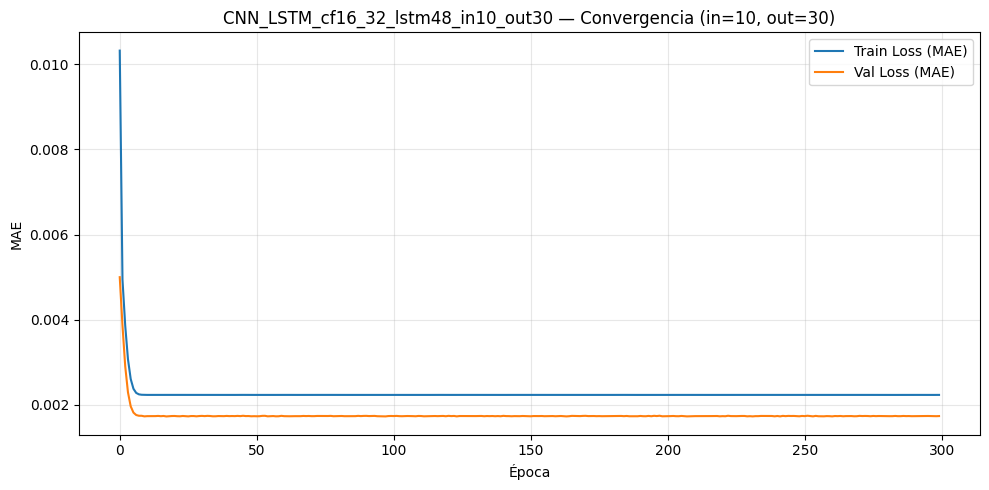

Modelo guardado en: models/CNN_LSTM_cf16_32_lstm48_in10_out30.keras


In [3]:
# ============================================================================
# ▶▶▶ CONFIGURACIÓN — CAMBIA AQUÍ LOS PARÁMETROS ◀◀◀
# ============================================================================

# --- Ventanas ---
INPUT_WINDOW  = 10
OUTPUT_WINDOW = 30

# --- Bloque convolucional ---
FILTERS_1     = 16          # Filtros primera Conv1D
KERNEL_SIZE_1 = 3           # Kernel primera Conv1D
FILTERS_2     = 32          # Filtros segunda Conv1D (0 para desactivar)
KERNEL_SIZE_2 = 3           # Kernel segunda Conv1D
PADDING       = 'same'      # Siempre 'same' para mantener resolución temporal
SPATIAL_DROP  = 0.0         # SpatialDropout1D tras cada conv (0 para desactivar)
USE_BATCHNORM = True        # BatchNormalization tras cada conv
L2_REG        = 0.0001      # Regularización L2 en capas conv (0 para desactivar)

# --- Bloque LSTM ---
LSTM_UNITS_1  = 48          # Unidades primera LSTM
LSTM_UNITS_2  = 0           # Unidades segunda LSTM (0 para desactivar)
LSTM_DROPOUT  = 0.05         # Dropout interno de la LSTM (recurrent_dropout)
LSTM_USE_GAP  = False       # True → GlobalAveragePooling sobre salida LSTM
                            # False → usa solo el último hidden state (por defecto)

# --- Bloque denso ---
DENSE_1       = 128          # Neuronas primera capa densa
DENSE_2       = 64          # Neuronas segunda capa densa (0 para desactivar)
DROPOUT_1     = 0.4         # Dropout tras primera densa
DROPOUT_2     = 0.5         # Dropout tras segunda densa

# --- Entrenamiento ---
LEARNING_RATE = 0.001
EPOCHS        = 300
BATCH_SIZE    = 32
MIN_DELTA     = 1e-5
VAL_SPLIT     = 0.1

# --- Nombre del modelo ---
MODEL_NAME = (
    f"CNN_LSTM"
    f"_cf{FILTERS_1}{'_'+str(FILTERS_2) if FILTERS_2 else ''}"
    f"_lstm{LSTM_UNITS_1}{'_'+str(LSTM_UNITS_2) if LSTM_UNITS_2 else ''}"
    f"_in{INPUT_WINDOW}_out{OUTPUT_WINDOW}"
)


# ============================================================================
# CONSTRUCCIÓN DEL MODELO
# ============================================================================

def build_cnn_lstm(input_window, n_features=23):

    reg = l2(L2_REG) if L2_REG > 0 else None

    inp = Input(shape=(input_window, n_features))
    x = inp

    # ── Bloque convolucional ──
    x = Conv1D(FILTERS_1, kernel_size=KERNEL_SIZE_1, padding=PADDING,
               activation='relu', kernel_regularizer=reg)(x)
    if USE_BATCHNORM:
        x = BatchNormalization()(x)
    if SPATIAL_DROP > 0:
        x = SpatialDropout1D(SPATIAL_DROP)(x)

    if FILTERS_2 > 0:
        x = Conv1D(FILTERS_2, kernel_size=KERNEL_SIZE_2, padding=PADDING,
                   activation='relu', kernel_regularizer=reg)(x)
        if USE_BATCHNORM:
            x = BatchNormalization()(x)
        if SPATIAL_DROP > 0:
            x = SpatialDropout1D(SPATIAL_DROP)(x)

    # En este punto: shape = (input_window, FILTERS_2 o FILTERS_1)
    # Es una secuencia temporal de features convolucionales → ideal para LSTM

    # ── Bloque LSTM ──
    return_sequences = (LSTM_UNITS_2 > 0) or LSTM_USE_GAP
    x = LSTM(
        LSTM_UNITS_1,
        return_sequences=return_sequences,
        dropout=LSTM_DROPOUT,
        recurrent_dropout=LSTM_DROPOUT
    )(x)

    if LSTM_UNITS_2 > 0:
        x = LSTM(
            LSTM_UNITS_2,
            return_sequences=LSTM_USE_GAP,
            dropout=LSTM_DROPOUT,
            recurrent_dropout=LSTM_DROPOUT
        )(x)

    if LSTM_USE_GAP:
        x = GlobalAveragePooling1D()(x)

    # ── Bloque denso ──
    x = Dense(DENSE_1, activation='relu')(x)
    if DROPOUT_1 > 0:
        x = Dropout(DROPOUT_1)(x)

    if DENSE_2 > 0:
        x = Dense(DENSE_2, activation='relu')(x)
        if DROPOUT_2 > 0:
            x = Dropout(DROPOUT_2)(x)

    # ── Salida ──
    out = Dense(n_features)(x)

    model = Model(inputs=inp, outputs=out)
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='mae'
    )
    return model


# ============================================================================
# CARGA DE DATOS
# ============================================================================

print("Cargando datos...")
returns = load_data()

X_train, X_test, y_train, y_test = get_train_test(returns, INPUT_WINDOW, OUTPUT_WINDOW)

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}   y_test:  {y_test.shape}")

# Validación temporal (último 10% del train, sin shuffle)
split_idx = int(len(X_train) * (1 - VAL_SPLIT))
X_tr,  y_tr  = X_train[:split_idx], y_train[:split_idx]
X_val, y_val = X_train[split_idx:], y_train[split_idx:]

print(f"Train:   {X_tr.shape}  Val: {X_val.shape}")


# ============================================================================
# CONSTRUCCIÓN E INSPECCIÓN
# ============================================================================

model = build_cnn_lstm(INPUT_WINDOW, n_features=X_train.shape[2])
n_params = count_parameters(model)

print(f"\n{'='*60}")
print(f"  Modelo: {MODEL_NAME}")
print(f"  Parámetros: {n_params:,}")
print(f"{'='*60}")
model.summary()


# ============================================================================
# ENTRENAMIENTO
# ============================================================================


history = model.fit(
    X_tr, y_tr,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),   # validación temporal, sin shuffle
    shuffle=True,                      # shuffle dentro del train está ok
    verbose=1
)

print(f"\nEntrenamiento detenido en la época {len(history.history['loss'])}")


# ============================================================================
# EVALUACIÓN
# ============================================================================

y_pred_train = model.predict(X_train, verbose=0)
y_pred_test  = model.predict(X_test, verbose=0)
y_pred_val   = model.predict(X_val, verbose=0)

mae_train = compute_mae(y_train, y_pred_train)
mae_val   = compute_mae(y_val, y_pred_val)
mae_test  = compute_mae(y_test, y_pred_test)

# Baseline: predecir cero
mae_zero = np.mean(np.abs(y_test))

print(f"\n{'='*60}")
print(f"  Resultados {MODEL_NAME}:")
print(f"    MAE Train:    {mae_train:.6f}")
print(f"    MAE Val:      {mae_val:.6f}")
print(f"    MAE Test:     {mae_test:.6f}")
print(f"    MAE Zero:     {mae_zero:.6f}  (baseline: predecir 0)")
print(f"    Mejora vs 0:  {(mae_zero - mae_test) / mae_zero * 100:.2f}%")
print(f"{'='*60}")

# Comprobar si el modelo predice algo o está "muerto"
y_pred_std = np.std(y_pred_test)
print(f"\n  Diagnóstico:")
print(f"    Std predicciones test: {y_pred_std:.6f}")
if y_pred_std < 1e-4:
    print("    ⚠️  Las predicciones tienen varianza ~0: el modelo predice constante.")
    print("    → Revisa el planteamiento (loss, features, target).")
else:
    print("    ✓  Las predicciones tienen varianza razonable.")


# ============================================================================
# GUARDAR RESULTADOS
# ============================================================================

save_results(
    model_name=MODEL_NAME,
    model_type='cnn_lstm',
    input_window=INPUT_WINDOW,
    output_window=OUTPUT_WINDOW,
    mae_train=mae_train,
    mae_test=mae_test,
    n_params=n_params,
    mae_val=mae_val
)

plot_training_curves(history, MODEL_NAME, INPUT_WINDOW, OUTPUT_WINDOW, save=True)

model_path = os.path.join(MODELS_DIR, f"{MODEL_NAME}.keras")
model.save(model_path)
print(f"Modelo guardado en: {model_path}")

Cargando datos...


[*********************100%***********************]  23 of 23 completed


Datos cargados: 16191 días, 23 activos
Rango: 1962-01-03 → 2026-05-04
Ventana entrada=10, salida=5
  X_train: (14559, 10, 23) | y_train: (14559, 23)
  X_test:  (1618, 10, 23)  | y_test:  (1618, 23)
X_train: (14559, 10, 23)  y_train: (14559, 23)
X_test:  (1618, 10, 23)   y_test:  (1618, 23)
Train:   (13103, 10, 23)  Val: (1456, 10, 23)

  Modelo: CNN_LSTM_cf16_32_lstm40_in10_out5
  Parámetros: 19,927


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 10, 23)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 10, 16)         │         1,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 10, 16)         │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_6             │ (None, 10, 16)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 10, 32)         │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 10, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_7             │ (None, 10, 32)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 40)             │        11,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,023 (78.21 KB)

 Trainable params: 19,927 (77.84 KB)

 Non-trainable params: 96 (384.00 B)

Epoch 1/300
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.1007 - val_loss: 0.0538
Epoch 2/300
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0867 - val_loss: 0.0761
Epoch 3/300
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0755 - val_loss: 0.0509
Epoch 4/300
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0658 - val_loss: 0.0314
Epoch 5/300
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0577 - val_loss: 0.0258
Epoch 6/300
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0509 - val_loss: 0.0218
Epoch 7/300
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0455 - val_loss: 0.0187
Epoch 8/300
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0401 - val_loss: 0.0165
Epoch 9/300
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0361 - val_loss: 0.0147
Epoch 10/300
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0323 - val_loss: 0.0134
Epoch 11/300
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0291 - val_loss: 0.0123
Epoch 12/300
205/205 ━━━━━━━━━━━━━━━━━━━━

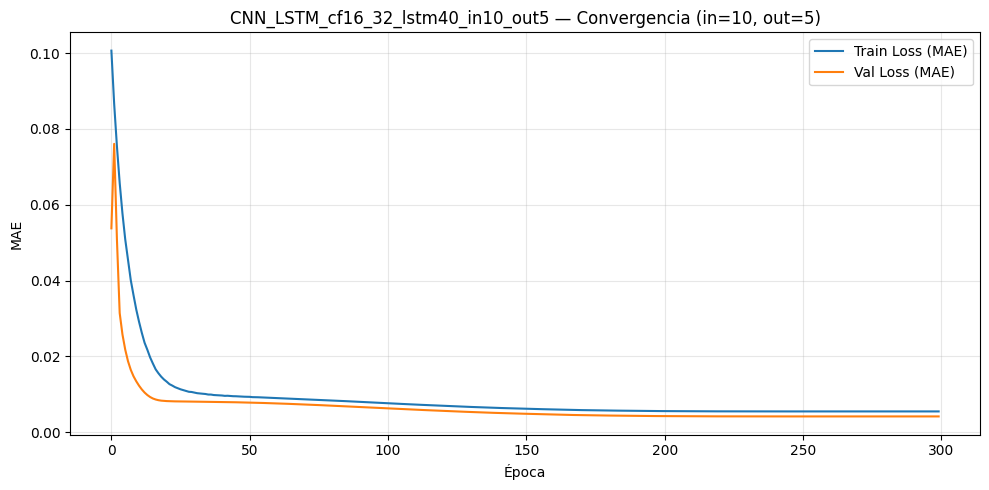

Modelo guardado en: models/CNN_LSTM_cf16_32_lstm40_in10_out5.keras


In [6]:
# ============================================================================
# ▶▶▶ CONFIGURACIÓN — CAMBIA AQUÍ LOS PARÁMETROS ◀◀◀
# ============================================================================

# --- Ventanas ---
INPUT_WINDOW  = 10
OUTPUT_WINDOW = 5

# --- Bloque convolucional ---
FILTERS_1     = 16          # Filtros primera Conv1D
KERNEL_SIZE_1 = 3           # Kernel primera Conv1D
FILTERS_2     = 32          # Filtros segunda Conv1D (0 para desactivar)
KERNEL_SIZE_2 = 3           # Kernel segunda Conv1D
PADDING       = 'same'      # Siempre 'same' para mantener resolución temporal
SPATIAL_DROP  = 0.1         # SpatialDropout1D tras cada conv (0 para desactivar)
USE_BATCHNORM = True        # BatchNormalization tras cada conv
L2_REG        = 0.0001      # Regularización L2 en capas conv (0 para desactivar)

# --- Bloque LSTM ---
LSTM_UNITS_1  = 40          # Unidades primera LSTM
LSTM_UNITS_2  = 0           # Unidades segunda LSTM (0 para desactivar)
LSTM_DROPOUT  = 0.05         # Dropout interno de la LSTM (recurrent_dropout)
LSTM_USE_GAP  = False       # True → GlobalAveragePooling sobre salida LSTM
                            # False → usa solo el último hidden state (por defecto)

# --- Bloque denso ---
DENSE_1       = 64          # Neuronas primera capa densa
DENSE_2       = 32          # Neuronas segunda capa densa (0 para desactivar)
DROPOUT_1     = 0.3         # Dropout tras primera densa
DROPOUT_2     = 0.4         # Dropout tras segunda densa

# --- Entrenamiento ---
LEARNING_RATE = 0.00001
EPOCHS        = 300
BATCH_SIZE    = 64
MIN_DELTA     = 1e-5
VAL_SPLIT     = 0.1

# --- Nombre del modelo ---
MODEL_NAME = (
    f"CNN_LSTM"
    f"_cf{FILTERS_1}{'_'+str(FILTERS_2) if FILTERS_2 else ''}"
    f"_lstm{LSTM_UNITS_1}{'_'+str(LSTM_UNITS_2) if LSTM_UNITS_2 else ''}"
    f"_in{INPUT_WINDOW}_out{OUTPUT_WINDOW}"
)


# ============================================================================
# CONSTRUCCIÓN DEL MODELO
# ============================================================================

def build_cnn_lstm(input_window, n_features=23):

    reg = l2(L2_REG) if L2_REG > 0 else None

    inp = Input(shape=(input_window, n_features))
    x = inp

    # ── Bloque convolucional ──
    x = Conv1D(FILTERS_1, kernel_size=KERNEL_SIZE_1, padding=PADDING,
               activation='relu', kernel_regularizer=reg)(x)
    if USE_BATCHNORM:
        x = BatchNormalization()(x)
    if SPATIAL_DROP > 0:
        x = SpatialDropout1D(SPATIAL_DROP)(x)

    if FILTERS_2 > 0:
        x = Conv1D(FILTERS_2, kernel_size=KERNEL_SIZE_2, padding=PADDING,
                   activation='relu', kernel_regularizer=reg)(x)
        if USE_BATCHNORM:
            x = BatchNormalization()(x)
        if SPATIAL_DROP > 0:
            x = SpatialDropout1D(SPATIAL_DROP)(x)

    # En este punto: shape = (input_window, FILTERS_2 o FILTERS_1)
    # Es una secuencia temporal de features convolucionales → ideal para LSTM

    # ── Bloque LSTM ──
    return_sequences = (LSTM_UNITS_2 > 0) or LSTM_USE_GAP
    x = LSTM(
        LSTM_UNITS_1,
        return_sequences=return_sequences,
        dropout=LSTM_DROPOUT,
        recurrent_dropout=LSTM_DROPOUT
    )(x)

    if LSTM_UNITS_2 > 0:
        x = LSTM(
            LSTM_UNITS_2,
            return_sequences=LSTM_USE_GAP,
            dropout=LSTM_DROPOUT,
            recurrent_dropout=LSTM_DROPOUT
        )(x)

    if LSTM_USE_GAP:
        x = GlobalAveragePooling1D()(x)

    # ── Bloque denso ──
    x = Dense(DENSE_1, activation='relu')(x)
    if DROPOUT_1 > 0:
        x = Dropout(DROPOUT_1)(x)

    if DENSE_2 > 0:
        x = Dense(DENSE_2, activation='relu')(x)
        if DROPOUT_2 > 0:
            x = Dropout(DROPOUT_2)(x)

    # ── Salida ──
    out = Dense(n_features)(x)

    model = Model(inputs=inp, outputs=out)
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='mae'
    )
    return model


# ============================================================================
# CARGA DE DATOS
# ============================================================================

print("Cargando datos...")
returns = load_data()

X_train, X_test, y_train, y_test = get_train_test(returns, INPUT_WINDOW, OUTPUT_WINDOW)

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}   y_test:  {y_test.shape}")

# Validación temporal (último 10% del train, sin shuffle)
split_idx = int(len(X_train) * (1 - VAL_SPLIT))
X_tr,  y_tr  = X_train[:split_idx], y_train[:split_idx]
X_val, y_val = X_train[split_idx:], y_train[split_idx:]

print(f"Train:   {X_tr.shape}  Val: {X_val.shape}")


# ============================================================================
# CONSTRUCCIÓN E INSPECCIÓN
# ============================================================================

model = build_cnn_lstm(INPUT_WINDOW, n_features=X_train.shape[2])
n_params = count_parameters(model)

print(f"\n{'='*60}")
print(f"  Modelo: {MODEL_NAME}")
print(f"  Parámetros: {n_params:,}")
print(f"{'='*60}")
model.summary()


# ============================================================================
# ENTRENAMIENTO
# ============================================================================


history = model.fit(
    X_tr, y_tr,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),   # validación temporal, sin shuffle
    shuffle=True,                      # shuffle dentro del train está ok
    verbose=1
)

print(f"\nEntrenamiento detenido en la época {len(history.history['loss'])}")


# ============================================================================
# EVALUACIÓN
# ============================================================================

y_pred_train = model.predict(X_train, verbose=0)
y_pred_test  = model.predict(X_test, verbose=0)
y_pred_val   = model.predict(X_val, verbose=0)

mae_train = compute_mae(y_train, y_pred_train)
mae_val   = compute_mae(y_val, y_pred_val)
mae_test  = compute_mae(y_test, y_pred_test)

# Baseline: predecir cero
mae_zero = np.mean(np.abs(y_test))

print(f"\n{'='*60}")
print(f"  Resultados {MODEL_NAME}:")
print(f"    MAE Train:    {mae_train:.6f}")
print(f"    MAE Val:      {mae_val:.6f}")
print(f"    MAE Test:     {mae_test:.6f}")
print(f"    MAE Zero:     {mae_zero:.6f}  (baseline: predecir 0)")
print(f"    Mejora vs 0:  {(mae_zero - mae_test) / mae_zero * 100:.2f}%")
print(f"{'='*60}")

# Comprobar si el modelo predice algo o está "muerto"
y_pred_std = np.std(y_pred_test)
print(f"\n  Diagnóstico:")
print(f"    Std predicciones test: {y_pred_std:.6f}")
if y_pred_std < 1e-4:
    print("    ⚠️  Las predicciones tienen varianza ~0: el modelo predice constante.")
    print("    → Revisa el planteamiento (loss, features, target).")
else:
    print("    ✓  Las predicciones tienen varianza razonable.")


# ============================================================================
# GUARDAR RESULTADOS
# ============================================================================

save_results(
    model_name=MODEL_NAME,
    model_type='cnn_lstm',
    input_window=INPUT_WINDOW,
    output_window=OUTPUT_WINDOW,
    mae_train=mae_train,
    mae_test=mae_test,
    n_params=n_params,
    mae_val=mae_val
)

plot_training_curves(history, MODEL_NAME, INPUT_WINDOW, OUTPUT_WINDOW, save=True)

model_path = os.path.join(MODELS_DIR, f"{MODEL_NAME}.keras")
model.save(model_path)
print(f"Modelo guardado en: {model_path}")

Cargando datos...


[*********************100%***********************]  23 of 23 completed


Datos cargados: 16191 días, 23 activos
Rango: 1962-01-03 → 2026-05-04
Ventana entrada=10, salida=1
  X_train: (14562, 10, 23) | y_train: (14562, 23)
  X_test:  (1619, 10, 23)  | y_test:  (1619, 23)
X_train: (14562, 10, 23)  y_train: (14562, 23)
X_test:  (1619, 10, 23)   y_test:  (1619, 23)
Train:   (13105, 10, 23)  Val: (1457, 10, 23)

  Modelo: CNN_LSTM_cf16_32_lstm32_in10_out1
  Parámetros: 12,919


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 10, 23)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_14 (Conv1D)              │ (None, 10, 16)         │         1,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 10, 16)         │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_15 (Conv1D)              │ (None, 10, 32)         │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 10, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,015 (50.84 KB)

 Trainable params: 12,919 (50.46 KB)

 Non-trainable params: 96 (384.00 B)

Epoch 1/300
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0638 - val_loss: 0.0212
Epoch 2/300
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0278 - val_loss: 0.0141
Epoch 3/300
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0184 - val_loss: 0.0130
Epoch 4/300
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0164 - val_loss: 0.0129
Epoch 5/300
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0159 - val_loss: 0.0128
Epoch 6/300
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0157 - val_loss: 0.0127
Epoch 7/300
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0156 - val_loss: 0.0126
Epoch 8/300
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0154 - val_loss: 0.0126
Epoch 9/300
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0153 - val_loss: 0.0125
Epoch 10/300
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0152 - val_loss: 0.0124
Epoch 11/300
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0151 - val_loss: 0.0123
Epoch 12/300
205/205 ━━━━━━━━━━━━━━━━━━━━

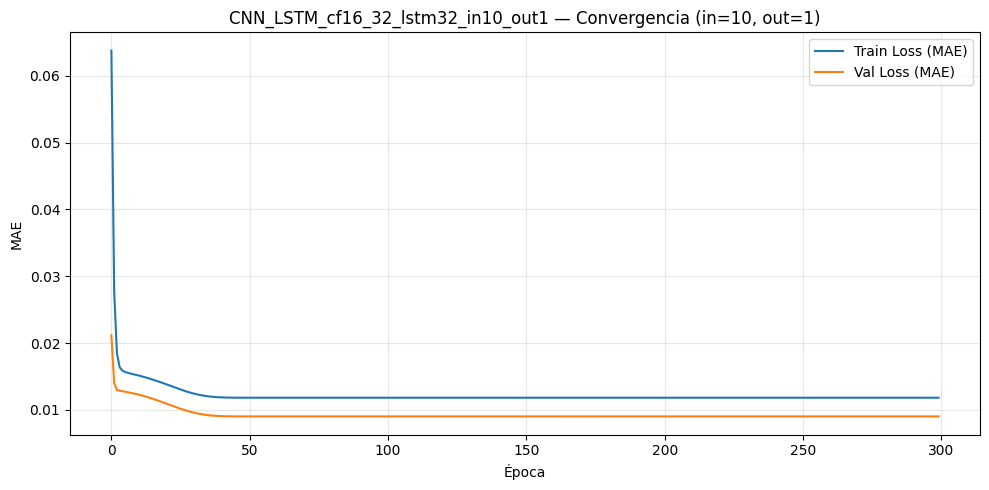

Modelo guardado en: models/CNN_LSTM_cf16_32_lstm32_in10_out1.keras


In [8]:
# ============================================================================
# ▶▶▶ CONFIGURACIÓN — CAMBIA AQUÍ LOS PARÁMETROS ◀◀◀
# ============================================================================

# --- Ventanas ---
INPUT_WINDOW  = 10
OUTPUT_WINDOW = 1

# --- Bloque convolucional ---
FILTERS_1     = 16          # Filtros primera Conv1D
KERNEL_SIZE_1 = 3           # Kernel primera Conv1D
FILTERS_2     = 32          # Filtros segunda Conv1D (0 para desactivar)
KERNEL_SIZE_2 = 3           # Kernel segunda Conv1D
PADDING       = 'same'      # Siempre 'same' para mantener resolución temporal
SPATIAL_DROP  = 0.0         # SpatialDropout1D tras cada conv (0 para desactivar)
USE_BATCHNORM = True        # BatchNormalization tras cada conv
L2_REG        = 0.0001      # Regularización L2 en capas conv (0 para desactivar)

# --- Bloque LSTM ---
LSTM_UNITS_1  = 32          # Unidades primera LSTM
LSTM_UNITS_2  = 0           # Unidades segunda LSTM (0 para desactivar)
LSTM_DROPOUT  = 0.05         # Dropout interno de la LSTM (recurrent_dropout)
LSTM_USE_GAP  = False       # True → GlobalAveragePooling sobre salida LSTM
                            # False → usa solo el último hidden state (por defecto)

# --- Bloque denso ---
DENSE_1       = 32          # Neuronas primera capa densa
DENSE_2       = 0          # Neuronas segunda capa densa (0 para desactivar)
DROPOUT_1     = 0.0         # Dropout tras primera densa
DROPOUT_2     = 0.4         # Dropout tras segunda densa

# --- Entrenamiento ---
LEARNING_RATE = 0.0001
EPOCHS        = 300
BATCH_SIZE    = 64
MIN_DELTA     = 1e-5
VAL_SPLIT     = 0.1

# --- Nombre del modelo ---
MODEL_NAME = (
    f"CNN_LSTM"
    f"_cf{FILTERS_1}{'_'+str(FILTERS_2) if FILTERS_2 else ''}"
    f"_lstm{LSTM_UNITS_1}{'_'+str(LSTM_UNITS_2) if LSTM_UNITS_2 else ''}"
    f"_in{INPUT_WINDOW}_out{OUTPUT_WINDOW}"
)


# ============================================================================
# CONSTRUCCIÓN DEL MODELO
# ============================================================================

def build_cnn_lstm(input_window, n_features=23):

    reg = l2(L2_REG) if L2_REG > 0 else None

    inp = Input(shape=(input_window, n_features))
    x = inp

    # ── Bloque convolucional ──
    x = Conv1D(FILTERS_1, kernel_size=KERNEL_SIZE_1, padding=PADDING,
               activation='relu', kernel_regularizer=reg)(x)
    if USE_BATCHNORM:
        x = BatchNormalization()(x)
    if SPATIAL_DROP > 0:
        x = SpatialDropout1D(SPATIAL_DROP)(x)

    if FILTERS_2 > 0:
        x = Conv1D(FILTERS_2, kernel_size=KERNEL_SIZE_2, padding=PADDING,
                   activation='relu', kernel_regularizer=reg)(x)
        if USE_BATCHNORM:
            x = BatchNormalization()(x)
        if SPATIAL_DROP > 0:
            x = SpatialDropout1D(SPATIAL_DROP)(x)

    # En este punto: shape = (input_window, FILTERS_2 o FILTERS_1)
    # Es una secuencia temporal de features convolucionales → ideal para LSTM

    # ── Bloque LSTM ──
    return_sequences = (LSTM_UNITS_2 > 0) or LSTM_USE_GAP
    x = LSTM(
        LSTM_UNITS_1,
        return_sequences=return_sequences,
        dropout=LSTM_DROPOUT,
        recurrent_dropout=LSTM_DROPOUT
    )(x)

    if LSTM_UNITS_2 > 0:
        x = LSTM(
            LSTM_UNITS_2,
            return_sequences=LSTM_USE_GAP,
            dropout=LSTM_DROPOUT,
            recurrent_dropout=LSTM_DROPOUT
        )(x)

    if LSTM_USE_GAP:
        x = GlobalAveragePooling1D()(x)

    # ── Bloque denso ──
    x = Dense(DENSE_1, activation='relu')(x)
    if DROPOUT_1 > 0:
        x = Dropout(DROPOUT_1)(x)

    if DENSE_2 > 0:
        x = Dense(DENSE_2, activation='relu')(x)
        if DROPOUT_2 > 0:
            x = Dropout(DROPOUT_2)(x)

    # ── Salida ──
    out = Dense(n_features)(x)

    model = Model(inputs=inp, outputs=out)
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='mae'
    )
    return model


# ============================================================================
# CARGA DE DATOS
# ============================================================================

print("Cargando datos...")
returns = load_data()

X_train, X_test, y_train, y_test = get_train_test(returns, INPUT_WINDOW, OUTPUT_WINDOW)

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}   y_test:  {y_test.shape}")

# Validación temporal (último 10% del train, sin shuffle)
split_idx = int(len(X_train) * (1 - VAL_SPLIT))
X_tr,  y_tr  = X_train[:split_idx], y_train[:split_idx]
X_val, y_val = X_train[split_idx:], y_train[split_idx:]

print(f"Train:   {X_tr.shape}  Val: {X_val.shape}")


# ============================================================================
# CONSTRUCCIÓN E INSPECCIÓN
# ============================================================================

model = build_cnn_lstm(INPUT_WINDOW, n_features=X_train.shape[2])
n_params = count_parameters(model)

print(f"\n{'='*60}")
print(f"  Modelo: {MODEL_NAME}")
print(f"  Parámetros: {n_params:,}")
print(f"{'='*60}")
model.summary()


# ============================================================================
# ENTRENAMIENTO
# ============================================================================


history = model.fit(
    X_tr, y_tr,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),   # validación temporal, sin shuffle
    shuffle=True,                      # shuffle dentro del train está ok
    verbose=1
)

print(f"\nEntrenamiento detenido en la época {len(history.history['loss'])}")


# ============================================================================
# EVALUACIÓN
# ============================================================================

y_pred_train = model.predict(X_train, verbose=0)
y_pred_test  = model.predict(X_test, verbose=0)
y_pred_val   = model.predict(X_val, verbose=0)

mae_train = compute_mae(y_train, y_pred_train)
mae_val   = compute_mae(y_val, y_pred_val)
mae_test  = compute_mae(y_test, y_pred_test)

# Baseline: predecir cero
mae_zero = np.mean(np.abs(y_test))

print(f"\n{'='*60}")
print(f"  Resultados {MODEL_NAME}:")
print(f"    MAE Train:    {mae_train:.6f}")
print(f"    MAE Val:      {mae_val:.6f}")
print(f"    MAE Test:     {mae_test:.6f}")
print(f"    MAE Zero:     {mae_zero:.6f}  (baseline: predecir 0)")
print(f"    Mejora vs 0:  {(mae_zero - mae_test) / mae_zero * 100:.2f}%")
print(f"{'='*60}")

# Comprobar si el modelo predice algo o está "muerto"
y_pred_std = np.std(y_pred_test)
print(f"\n  Diagnóstico:")
print(f"    Std predicciones test: {y_pred_std:.6f}")
if y_pred_std < 1e-4:
    print("    ⚠️  Las predicciones tienen varianza ~0: el modelo predice constante.")
    print("    → Revisa el planteamiento (loss, features, target).")
else:
    print("    ✓  Las predicciones tienen varianza razonable.")


# ============================================================================
# GUARDAR RESULTADOS
# ============================================================================

save_results(
    model_name=MODEL_NAME,
    model_type='cnn_lstm',
    input_window=INPUT_WINDOW,
    output_window=OUTPUT_WINDOW,
    mae_train=mae_train,
    mae_test=mae_test,
    n_params=n_params,
    mae_val=mae_val
)

plot_training_curves(history, MODEL_NAME, INPUT_WINDOW, OUTPUT_WINDOW, save=True)

model_path = os.path.join(MODELS_DIR, f"{MODEL_NAME}.keras")
model.save(model_path)
print(f"Modelo guardado en: {model_path}")

Cargando datos...


[*********************100%***********************]  23 of 23 completed


Datos cargados: 16191 días, 23 activos
Rango: 1962-01-03 → 2026-05-04
Ventana entrada=5, salida=90
  X_train: (14487, 5, 23) | y_train: (14487, 23)
  X_test:  (1610, 5, 23)  | y_test:  (1610, 23)
X_train: (14487, 5, 23)  y_train: (14487, 23)
X_test:  (1610, 5, 23)   y_test:  (1610, 23)
Train:   (13038, 5, 23)  Val: (1449, 5, 23)

  Modelo: CNN_LSTM_cf16_lstm24_in5_out90
  Parámetros: 18,039


Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 5, 23)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_17 (Conv1D)              │ (None, 5, 16)          │         1,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 5, 16)          │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 24)             │         3,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 128)            │         3,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 23)             │         1,495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,071 (70.59 KB)

 Trainable params: 18,039 (70.46 KB)

 Non-trainable params: 32 (128.00 B)

Epoch 1/300
408/408 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0030 - val_loss: 0.0016
Epoch 2/300
408/408 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0016 - val_loss: 0.0011
Epoch 3/300
408/408 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0013 - val_loss: 9.7614e-04
Epoch 4/300
408/408 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0013 - val_loss: 9.6010e-04
Epoch 5/300
408/408 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0013 - val_loss: 9.5684e-04
Epoch 6/300
408/408 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0013 - val_loss: 9.5466e-04
Epoch 7/300
408/408 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0013 - val_loss: 9.6156e-04
Epoch 8/300
408/408 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0013 - val_loss: 9.5895e-04
Epoch 9/300
408/408 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0013 - val_loss: 9.5912e-04
Epoch 10/300
408/408 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0013 - val_loss: 9.5637e-04
Epoch 11/300
408/408 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0013 - val_loss: 9.6181e-04
Epoch

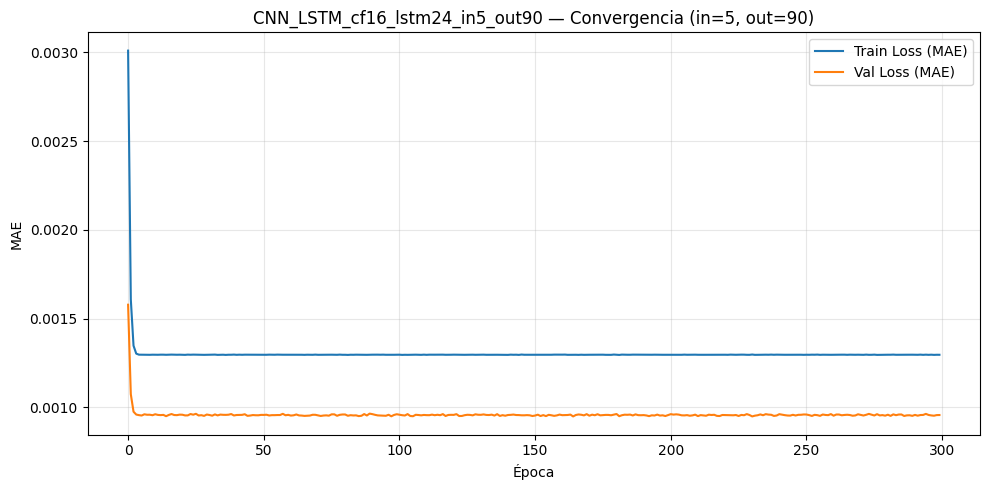

Modelo guardado en: models/CNN_LSTM_cf16_lstm24_in5_out90.keras


In [10]:
# ============================================================================
# ▶▶▶ CONFIGURACIÓN — CAMBIA AQUÍ LOS PARÁMETROS ◀◀◀
# ============================================================================

# --- Ventanas ---
INPUT_WINDOW  = 5
OUTPUT_WINDOW = 90

# --- Bloque convolucional ---
FILTERS_1     = 16          # Filtros primera Conv1D
KERNEL_SIZE_1 = 3           # Kernel primera Conv1D
FILTERS_2     = 0          # Filtros segunda Conv1D (0 para desactivar)
KERNEL_SIZE_2 = 3           # Kernel segunda Conv1D
PADDING       = 'same'      # Siempre 'same' para mantener resolución temporal
SPATIAL_DROP  = 0.0         # SpatialDropout1D tras cada conv (0 para desactivar)
USE_BATCHNORM = True        # BatchNormalization tras cada conv
L2_REG        = 0.0001      # Regularización L2 en capas conv (0 para desactivar)

# --- Bloque LSTM ---
LSTM_UNITS_1  = 24          # Unidades primera LSTM
LSTM_UNITS_2  = 0           # Unidades segunda LSTM (0 para desactivar)
LSTM_DROPOUT  = 0.05         # Dropout interno de la LSTM (recurrent_dropout)
LSTM_USE_GAP  = False       # True → GlobalAveragePooling sobre salida LSTM
                            # False → usa solo el último hidden state (por defecto)

# --- Bloque denso ---
DENSE_1       = 128          # Neuronas primera capa densa
DENSE_2       = 64          # Neuronas segunda capa densa (0 para desactivar)
DROPOUT_1     = 0.4         # Dropout tras primera densa
DROPOUT_2     = 0.5         # Dropout tras segunda densa

# --- Entrenamiento ---
LEARNING_RATE = 0.001
EPOCHS        = 300
BATCH_SIZE    = 32
MIN_DELTA     = 1e-5
VAL_SPLIT     = 0.1

# --- Nombre del modelo ---
MODEL_NAME = (
    f"CNN_LSTM"
    f"_cf{FILTERS_1}{'_'+str(FILTERS_2) if FILTERS_2 else ''}"
    f"_lstm{LSTM_UNITS_1}{'_'+str(LSTM_UNITS_2) if LSTM_UNITS_2 else ''}"
    f"_in{INPUT_WINDOW}_out{OUTPUT_WINDOW}"
)


# ============================================================================
# CONSTRUCCIÓN DEL MODELO
# ============================================================================

def build_cnn_lstm(input_window, n_features=23):

    reg = l2(L2_REG) if L2_REG > 0 else None

    inp = Input(shape=(input_window, n_features))
    x = inp

    # ── Bloque convolucional ──
    x = Conv1D(FILTERS_1, kernel_size=KERNEL_SIZE_1, padding=PADDING,
               activation='relu', kernel_regularizer=reg)(x)
    if USE_BATCHNORM:
        x = BatchNormalization()(x)
    if SPATIAL_DROP > 0:
        x = SpatialDropout1D(SPATIAL_DROP)(x)

    if FILTERS_2 > 0:
        x = Conv1D(FILTERS_2, kernel_size=KERNEL_SIZE_2, padding=PADDING,
                   activation='relu', kernel_regularizer=reg)(x)
        if USE_BATCHNORM:
            x = BatchNormalization()(x)
        if SPATIAL_DROP > 0:
            x = SpatialDropout1D(SPATIAL_DROP)(x)

    # En este punto: shape = (input_window, FILTERS_2 o FILTERS_1)
    # Es una secuencia temporal de features convolucionales → ideal para LSTM

    # ── Bloque LSTM ──
    return_sequences = (LSTM_UNITS_2 > 0) or LSTM_USE_GAP
    x = LSTM(
        LSTM_UNITS_1,
        return_sequences=return_sequences,
        dropout=LSTM_DROPOUT,
        recurrent_dropout=LSTM_DROPOUT
    )(x)

    if LSTM_UNITS_2 > 0:
        x = LSTM(
            LSTM_UNITS_2,
            return_sequences=LSTM_USE_GAP,
            dropout=LSTM_DROPOUT,
            recurrent_dropout=LSTM_DROPOUT
        )(x)

    if LSTM_USE_GAP:
        x = GlobalAveragePooling1D()(x)

    # ── Bloque denso ──
    x = Dense(DENSE_1, activation='relu')(x)
    if DROPOUT_1 > 0:
        x = Dropout(DROPOUT_1)(x)

    if DENSE_2 > 0:
        x = Dense(DENSE_2, activation='relu')(x)
        if DROPOUT_2 > 0:
            x = Dropout(DROPOUT_2)(x)

    # ── Salida ──
    out = Dense(n_features)(x)

    model = Model(inputs=inp, outputs=out)
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='mae'
    )
    return model


# ============================================================================
# CARGA DE DATOS
# ============================================================================

print("Cargando datos...")
returns = load_data()

X_train, X_test, y_train, y_test = get_train_test(returns, INPUT_WINDOW, OUTPUT_WINDOW)

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}   y_test:  {y_test.shape}")

# Validación temporal (último 10% del train, sin shuffle)
split_idx = int(len(X_train) * (1 - VAL_SPLIT))
X_tr,  y_tr  = X_train[:split_idx], y_train[:split_idx]
X_val, y_val = X_train[split_idx:], y_train[split_idx:]

print(f"Train:   {X_tr.shape}  Val: {X_val.shape}")


# ============================================================================
# CONSTRUCCIÓN E INSPECCIÓN
# ============================================================================

model = build_cnn_lstm(INPUT_WINDOW, n_features=X_train.shape[2])
n_params = count_parameters(model)

print(f"\n{'='*60}")
print(f"  Modelo: {MODEL_NAME}")
print(f"  Parámetros: {n_params:,}")
print(f"{'='*60}")
model.summary()


# ============================================================================
# ENTRENAMIENTO
# ============================================================================


history = model.fit(
    X_tr, y_tr,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),   # validación temporal, sin shuffle
    shuffle=True,                      # shuffle dentro del train está ok
    verbose=1
)

print(f"\nEntrenamiento detenido en la época {len(history.history['loss'])}")


# ============================================================================
# EVALUACIÓN
# ============================================================================

y_pred_train = model.predict(X_train, verbose=0)
y_pred_test  = model.predict(X_test, verbose=0)
y_pred_val   = model.predict(X_val, verbose=0)

mae_train = compute_mae(y_train, y_pred_train)
mae_val   = compute_mae(y_val, y_pred_val)
mae_test  = compute_mae(y_test, y_pred_test)

# Baseline: predecir cero
mae_zero = np.mean(np.abs(y_test))

print(f"\n{'='*60}")
print(f"  Resultados {MODEL_NAME}:")
print(f"    MAE Train:    {mae_train:.6f}")
print(f"    MAE Val:      {mae_val:.6f}")
print(f"    MAE Test:     {mae_test:.6f}")
print(f"    MAE Zero:     {mae_zero:.6f}  (baseline: predecir 0)")
print(f"    Mejora vs 0:  {(mae_zero - mae_test) / mae_zero * 100:.2f}%")
print(f"{'='*60}")

# Comprobar si el modelo predice algo o está "muerto"
y_pred_std = np.std(y_pred_test)
print(f"\n  Diagnóstico:")
print(f"    Std predicciones test: {y_pred_std:.6f}")
if y_pred_std < 1e-4:
    print("    ⚠️  Las predicciones tienen varianza ~0: el modelo predice constante.")
    print("    → Revisa el planteamiento (loss, features, target).")
else:
    print("    ✓  Las predicciones tienen varianza razonable.")


# ============================================================================
# GUARDAR RESULTADOS
# ============================================================================

save_results(
    model_name=MODEL_NAME,
    model_type='cnn_lstm',
    input_window=INPUT_WINDOW,
    output_window=OUTPUT_WINDOW,
    mae_train=mae_train,
    mae_test=mae_test,
    n_params=n_params,
    mae_val=mae_val
)

plot_training_curves(history, MODEL_NAME, INPUT_WINDOW, OUTPUT_WINDOW, save=True)

model_path = os.path.join(MODELS_DIR, f"{MODEL_NAME}.keras")
model.save(model_path)
print(f"Modelo guardado en: {model_path}")

Cargando datos...


[*********************100%***********************]  23 of 23 completed


Datos cargados: 16191 días, 23 activos
Rango: 1962-01-03 → 2026-05-04
Ventana entrada=5, salida=30
  X_train: (14541, 5, 23) | y_train: (14541, 23)
  X_test:  (1616, 5, 23)  | y_test:  (1616, 23)
X_train: (14541, 5, 23)  y_train: (14541, 23)
X_test:  (1616, 5, 23)   y_test:  (1616, 23)
Train:   (13086, 5, 23)  Val: (1455, 5, 23)

  Modelo: CNN_LSTM_cf16_lstm24_in5_out30
  Parámetros: 18,039


Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 5, 23)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_19 (Conv1D)              │ (None, 5, 16)          │         1,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 5, 16)          │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 24)             │         3,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 128)            │         3,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 23)             │         1,495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,071 (70.59 KB)

 Trainable params: 18,039 (70.46 KB)

 Non-trainable params: 32 (128.00 B)

Epoch 1/300
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0294 - val_loss: 0.0039
Epoch 2/300
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0221 - val_loss: 0.0045
Epoch 3/300
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0169 - val_loss: 0.0048
Epoch 4/300
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0130 - val_loss: 0.0049
Epoch 5/300
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0102 - val_loss: 0.0044
Epoch 6/300
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0083 - val_loss: 0.0039
Epoch 7/300
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0071 - val_loss: 0.0037
Epoch 8/300
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0063 - val_loss: 0.0036
Epoch 9/300
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0057 - val_loss: 0.0035
Epoch 10/300
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0054 - val_loss: 0.0035
Epoch 11/300
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0051 - val_loss: 0.0035
Epoch 12/300
205/205 ━━━━━━━━━━━━━━━━━━━━

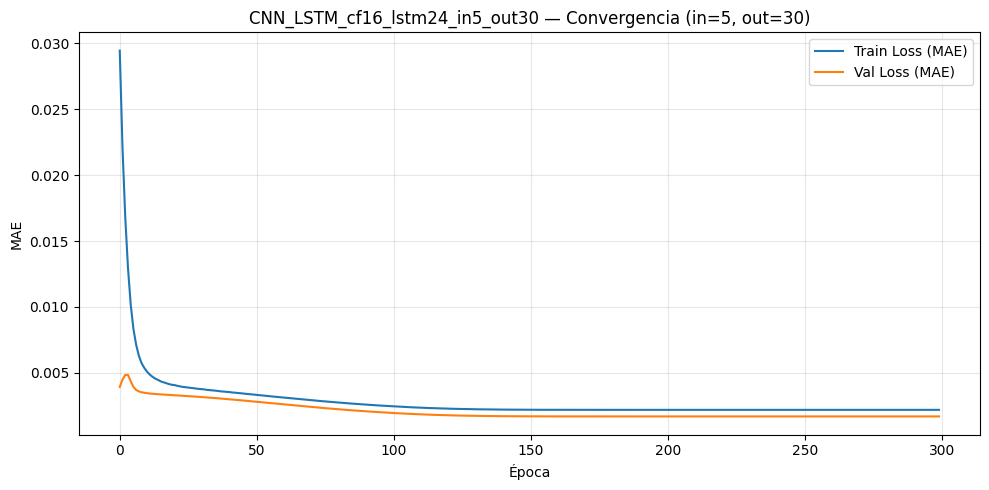

Modelo guardado en: models/CNN_LSTM_cf16_lstm24_in5_out30.keras


In [12]:
# ============================================================================
# ▶▶▶ CONFIGURACIÓN — CAMBIA AQUÍ LOS PARÁMETROS ◀◀◀
# ============================================================================

# --- Ventanas ---
INPUT_WINDOW  = 5
OUTPUT_WINDOW = 30

# --- Bloque convolucional ---
FILTERS_1     = 16          # Filtros primera Conv1D
KERNEL_SIZE_1 = 3           # Kernel primera Conv1D
FILTERS_2     = 0          # Filtros segunda Conv1D (0 para desactivar)
KERNEL_SIZE_2 = 3           # Kernel segunda Conv1D
PADDING       = 'same'      # Siempre 'same' para mantener resolución temporal
SPATIAL_DROP  = 0.0         # SpatialDropout1D tras cada conv (0 para desactivar)
USE_BATCHNORM = True        # BatchNormalization tras cada conv
L2_REG        = 0.0001      # Regularización L2 en capas conv (0 para desactivar)

# --- Bloque LSTM ---
LSTM_UNITS_1  = 24          # Unidades primera LSTM
LSTM_UNITS_2  = 0           # Unidades segunda LSTM (0 para desactivar)
LSTM_DROPOUT  = 0.05         # Dropout interno de la LSTM (recurrent_dropout)
LSTM_USE_GAP  = False       # True → GlobalAveragePooling sobre salida LSTM
                            # False → usa solo el último hidden state (por defecto)

# --- Bloque denso ---
DENSE_1       = 128          # Neuronas primera capa densa
DENSE_2       = 64          # Neuronas segunda capa densa (0 para desactivar)
DROPOUT_1     = 0.4         # Dropout tras primera densa
DROPOUT_2     = 0.5         # Dropout tras segunda densa

# --- Entrenamiento ---
LEARNING_RATE = 0.00001
EPOCHS        = 300
BATCH_SIZE    = 64
MIN_DELTA     = 1e-5
VAL_SPLIT     = 0.1

# --- Nombre del modelo ---
MODEL_NAME = (
    f"CNN_LSTM"
    f"_cf{FILTERS_1}{'_'+str(FILTERS_2) if FILTERS_2 else ''}"
    f"_lstm{LSTM_UNITS_1}{'_'+str(LSTM_UNITS_2) if LSTM_UNITS_2 else ''}"
    f"_in{INPUT_WINDOW}_out{OUTPUT_WINDOW}"
)


# ============================================================================
# CONSTRUCCIÓN DEL MODELO
# ============================================================================

def build_cnn_lstm(input_window, n_features=23):

    reg = l2(L2_REG) if L2_REG > 0 else None

    inp = Input(shape=(input_window, n_features))
    x = inp

    # ── Bloque convolucional ──
    x = Conv1D(FILTERS_1, kernel_size=KERNEL_SIZE_1, padding=PADDING,
               activation='relu', kernel_regularizer=reg)(x)
    if USE_BATCHNORM:
        x = BatchNormalization()(x)
    if SPATIAL_DROP > 0:
        x = SpatialDropout1D(SPATIAL_DROP)(x)

    if FILTERS_2 > 0:
        x = Conv1D(FILTERS_2, kernel_size=KERNEL_SIZE_2, padding=PADDING,
                   activation='relu', kernel_regularizer=reg)(x)
        if USE_BATCHNORM:
            x = BatchNormalization()(x)
        if SPATIAL_DROP > 0:
            x = SpatialDropout1D(SPATIAL_DROP)(x)

    # En este punto: shape = (input_window, FILTERS_2 o FILTERS_1)
    # Es una secuencia temporal de features convolucionales → ideal para LSTM

    # ── Bloque LSTM ──
    return_sequences = (LSTM_UNITS_2 > 0) or LSTM_USE_GAP
    x = LSTM(
        LSTM_UNITS_1,
        return_sequences=return_sequences,
        dropout=LSTM_DROPOUT,
        recurrent_dropout=LSTM_DROPOUT
    )(x)

    if LSTM_UNITS_2 > 0:
        x = LSTM(
            LSTM_UNITS_2,
            return_sequences=LSTM_USE_GAP,
            dropout=LSTM_DROPOUT,
            recurrent_dropout=LSTM_DROPOUT
        )(x)

    if LSTM_USE_GAP:
        x = GlobalAveragePooling1D()(x)

    # ── Bloque denso ──
    x = Dense(DENSE_1, activation='relu')(x)
    if DROPOUT_1 > 0:
        x = Dropout(DROPOUT_1)(x)

    if DENSE_2 > 0:
        x = Dense(DENSE_2, activation='relu')(x)
        if DROPOUT_2 > 0:
            x = Dropout(DROPOUT_2)(x)

    # ── Salida ──
    out = Dense(n_features)(x)

    model = Model(inputs=inp, outputs=out)
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='mae'
    )
    return model


# ============================================================================
# CARGA DE DATOS
# ============================================================================

print("Cargando datos...")
returns = load_data()

X_train, X_test, y_train, y_test = get_train_test(returns, INPUT_WINDOW, OUTPUT_WINDOW)

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}   y_test:  {y_test.shape}")

# Validación temporal (último 10% del train, sin shuffle)
split_idx = int(len(X_train) * (1 - VAL_SPLIT))
X_tr,  y_tr  = X_train[:split_idx], y_train[:split_idx]
X_val, y_val = X_train[split_idx:], y_train[split_idx:]

print(f"Train:   {X_tr.shape}  Val: {X_val.shape}")


# ============================================================================
# CONSTRUCCIÓN E INSPECCIÓN
# ============================================================================

model = build_cnn_lstm(INPUT_WINDOW, n_features=X_train.shape[2])
n_params = count_parameters(model)

print(f"\n{'='*60}")
print(f"  Modelo: {MODEL_NAME}")
print(f"  Parámetros: {n_params:,}")
print(f"{'='*60}")
model.summary()


# ============================================================================
# ENTRENAMIENTO
# ============================================================================


history = model.fit(
    X_tr, y_tr,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),   # validación temporal, sin shuffle
    shuffle=True,                      # shuffle dentro del train está ok
    verbose=1
)

print(f"\nEntrenamiento detenido en la época {len(history.history['loss'])}")


# ============================================================================
# EVALUACIÓN
# ============================================================================

y_pred_train = model.predict(X_train, verbose=0)
y_pred_test  = model.predict(X_test, verbose=0)
y_pred_val   = model.predict(X_val, verbose=0)

mae_train = compute_mae(y_train, y_pred_train)
mae_val   = compute_mae(y_val, y_pred_val)
mae_test  = compute_mae(y_test, y_pred_test)

# Baseline: predecir cero
mae_zero = np.mean(np.abs(y_test))

print(f"\n{'='*60}")
print(f"  Resultados {MODEL_NAME}:")
print(f"    MAE Train:    {mae_train:.6f}")
print(f"    MAE Val:      {mae_val:.6f}")
print(f"    MAE Test:     {mae_test:.6f}")
print(f"    MAE Zero:     {mae_zero:.6f}  (baseline: predecir 0)")
print(f"    Mejora vs 0:  {(mae_zero - mae_test) / mae_zero * 100:.2f}%")
print(f"{'='*60}")

# Comprobar si el modelo predice algo o está "muerto"
y_pred_std = np.std(y_pred_test)
print(f"\n  Diagnóstico:")
print(f"    Std predicciones test: {y_pred_std:.6f}")
if y_pred_std < 1e-4:
    print("    ⚠️  Las predicciones tienen varianza ~0: el modelo predice constante.")
    print("    → Revisa el planteamiento (loss, features, target).")
else:
    print("    ✓  Las predicciones tienen varianza razonable.")


# ============================================================================
# GUARDAR RESULTADOS
# ============================================================================

save_results(
    model_name=MODEL_NAME,
    model_type='cnn_lstm',
    input_window=INPUT_WINDOW,
    output_window=OUTPUT_WINDOW,
    mae_train=mae_train,
    mae_test=mae_test,
    n_params=n_params,
    mae_val=mae_val
)

plot_training_curves(history, MODEL_NAME, INPUT_WINDOW, OUTPUT_WINDOW, save=True)

model_path = os.path.join(MODELS_DIR, f"{MODEL_NAME}.keras")
model.save(model_path)
print(f"Modelo guardado en: {model_path}")

Cargando datos...


[*********************100%***********************]  23 of 23 completed


Datos cargados: 16191 días, 23 activos
Rango: 1962-01-03 → 2026-05-04
Ventana entrada=5, salida=5
  X_train: (14563, 5, 23) | y_train: (14563, 23)
  X_test:  (1619, 5, 23)  | y_test:  (1619, 23)
X_train: (14563, 5, 23)  y_train: (14563, 23)
X_test:  (1619, 5, 23)   y_test:  (1619, 23)
Train:   (13106, 5, 23)  Val: (1457, 5, 23)

  Modelo: CNN_LSTM_cf64_lstm20_in5_out5
  Parámetros: 15,591


Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_17 (InputLayer)     │ (None, 5, 23)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_25 (Conv1D)              │ (None, 5, 64)          │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 5, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_8             │ (None, 5, 64)          │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_17 (LSTM)                  │ (None, 20)             │         6,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,719 (61.40 KB)

 Trainable params: 15,591 (60.90 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/300
205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0196 - val_loss: 0.0044
Epoch 2/300
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0147 - val_loss: 0.0048
Epoch 3/300
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0115 - val_loss: 0.0052
Epoch 4/300
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0095 - val_loss: 0.0054
Epoch 5/300
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0083 - val_loss: 0.0050
Epoch 6/300
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0075 - val_loss: 0.0047
Epoch 7/300
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0068 - val_loss: 0.0045
Epoch 8/300
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0065 - val_loss: 0.0043
Epoch 9/300
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0062 - val_loss: 0.0043
Epoch 10/300
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0060 - val_loss: 0.0042
Epoch 11/300
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0059 - val_loss: 0.0042
Epoch 12/300
205/205 ━━━━━━━━━━━━━━━━━━━━

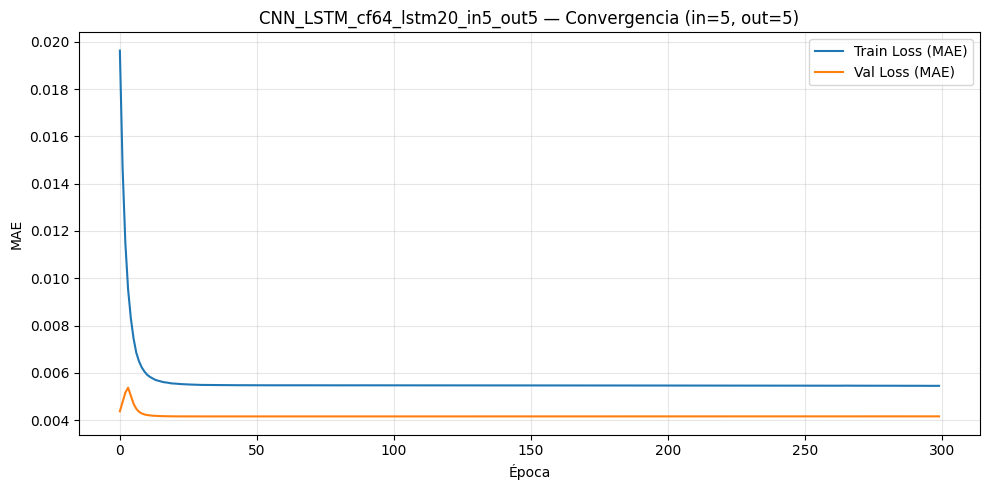

Modelo guardado en: models/CNN_LSTM_cf64_lstm20_in5_out5.keras


In [18]:
# ============================================================================
# ▶▶▶ CONFIGURACIÓN — CAMBIA AQUÍ LOS PARÁMETROS ◀◀◀
# ============================================================================

# --- Ventanas ---
INPUT_WINDOW  = 5
OUTPUT_WINDOW = 5

# --- Bloque convolucional ---
FILTERS_1     = 64          # Filtros primera Conv1D
KERNEL_SIZE_1 = 3           # Kernel primera Conv1D
FILTERS_2     = 0          # Filtros segunda Conv1D (0 para desactivar)
KERNEL_SIZE_2 = 3           # Kernel segunda Conv1D
PADDING       = 'same'      # Siempre 'same' para mantener resolución temporal
SPATIAL_DROP  = 0.1         # SpatialDropout1D tras cada conv (0 para desactivar)
USE_BATCHNORM = True        # BatchNormalization tras cada conv
L2_REG        = 0.000      # Regularización L2 en capas conv (0 para desactivar)

# --- Bloque LSTM ---
LSTM_UNITS_1  = 20          # Unidades primera LSTM
LSTM_UNITS_2  = 0           # Unidades segunda LSTM (0 para desactivar)
LSTM_DROPOUT  = 0.05         # Dropout interno de la LSTM (recurrent_dropout)
LSTM_USE_GAP  = False       # True → GlobalAveragePooling sobre salida LSTM
                            # False → usa solo el último hidden state (por defecto)

# --- Bloque denso ---
DENSE_1       = 64          # Neuronas primera capa densa
DENSE_2       = 32          # Neuronas segunda capa densa (0 para desactivar)
DROPOUT_1     = 0.0         # Dropout tras primera densa
DROPOUT_2     = 0.1         # Dropout tras segunda densa

# --- Entrenamiento ---
LEARNING_RATE = 0.00001
EPOCHS        = 300
BATCH_SIZE    = 64
MIN_DELTA     = 1e-5
VAL_SPLIT     = 0.1

# --- Nombre del modelo ---
MODEL_NAME = (
    f"CNN_LSTM"
    f"_cf{FILTERS_1}{'_'+str(FILTERS_2) if FILTERS_2 else ''}"
    f"_lstm{LSTM_UNITS_1}{'_'+str(LSTM_UNITS_2) if LSTM_UNITS_2 else ''}"
    f"_in{INPUT_WINDOW}_out{OUTPUT_WINDOW}"
)


# ============================================================================
# CONSTRUCCIÓN DEL MODELO
# ============================================================================

def build_cnn_lstm(input_window, n_features=23):

    reg = l2(L2_REG) if L2_REG > 0 else None

    inp = Input(shape=(input_window, n_features))
    x = inp

    # ── Bloque convolucional ──
    x = Conv1D(FILTERS_1, kernel_size=KERNEL_SIZE_1, padding=PADDING,
               activation='relu', kernel_regularizer=reg)(x)
    if USE_BATCHNORM:
        x = BatchNormalization()(x)
    if SPATIAL_DROP > 0:
        x = SpatialDropout1D(SPATIAL_DROP)(x)

    if FILTERS_2 > 0:
        x = Conv1D(FILTERS_2, kernel_size=KERNEL_SIZE_2, padding=PADDING,
                   activation='relu', kernel_regularizer=reg)(x)
        if USE_BATCHNORM:
            x = BatchNormalization()(x)
        if SPATIAL_DROP > 0:
            x = SpatialDropout1D(SPATIAL_DROP)(x)

    # En este punto: shape = (input_window, FILTERS_2 o FILTERS_1)
    # Es una secuencia temporal de features convolucionales → ideal para LSTM

    # ── Bloque LSTM ──
    return_sequences = (LSTM_UNITS_2 > 0) or LSTM_USE_GAP
    x = LSTM(
        LSTM_UNITS_1,
        return_sequences=return_sequences,
        dropout=LSTM_DROPOUT,
        recurrent_dropout=LSTM_DROPOUT
    )(x)

    if LSTM_UNITS_2 > 0:
        x = LSTM(
            LSTM_UNITS_2,
            return_sequences=LSTM_USE_GAP,
            dropout=LSTM_DROPOUT,
            recurrent_dropout=LSTM_DROPOUT
        )(x)

    if LSTM_USE_GAP:
        x = GlobalAveragePooling1D()(x)

    # ── Bloque denso ──
    x = Dense(DENSE_1, activation='relu')(x)
    if DROPOUT_1 > 0:
        x = Dropout(DROPOUT_1)(x)

    if DENSE_2 > 0:
        x = Dense(DENSE_2, activation='relu')(x)
        if DROPOUT_2 > 0:
            x = Dropout(DROPOUT_2)(x)

    # ── Salida ──
    out = Dense(n_features)(x)

    model = Model(inputs=inp, outputs=out)
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='mae'
    )
    return model


# ============================================================================
# CARGA DE DATOS
# ============================================================================

print("Cargando datos...")
returns = load_data()

X_train, X_test, y_train, y_test = get_train_test(returns, INPUT_WINDOW, OUTPUT_WINDOW)

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}   y_test:  {y_test.shape}")

# Validación temporal (último 10% del train, sin shuffle)
split_idx = int(len(X_train) * (1 - VAL_SPLIT))
X_tr,  y_tr  = X_train[:split_idx], y_train[:split_idx]
X_val, y_val = X_train[split_idx:], y_train[split_idx:]

print(f"Train:   {X_tr.shape}  Val: {X_val.shape}")


# ============================================================================
# CONSTRUCCIÓN E INSPECCIÓN
# ============================================================================

model = build_cnn_lstm(INPUT_WINDOW, n_features=X_train.shape[2])
n_params = count_parameters(model)

print(f"\n{'='*60}")
print(f"  Modelo: {MODEL_NAME}")
print(f"  Parámetros: {n_params:,}")
print(f"{'='*60}")
model.summary()


# ============================================================================
# ENTRENAMIENTO
# ============================================================================


history = model.fit(
    X_tr, y_tr,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),   # validación temporal, sin shuffle
    shuffle=True,                      # shuffle dentro del train está ok
    verbose=1
)

print(f"\nEntrenamiento detenido en la época {len(history.history['loss'])}")


# ============================================================================
# EVALUACIÓN
# ============================================================================

y_pred_train = model.predict(X_train, verbose=0)
y_pred_test  = model.predict(X_test, verbose=0)
y_pred_val   = model.predict(X_val, verbose=0)

mae_train = compute_mae(y_train, y_pred_train)
mae_val   = compute_mae(y_val, y_pred_val)
mae_test  = compute_mae(y_test, y_pred_test)

# Baseline: predecir cero
mae_zero = np.mean(np.abs(y_test))

print(f"\n{'='*60}")
print(f"  Resultados {MODEL_NAME}:")
print(f"    MAE Train:    {mae_train:.6f}")
print(f"    MAE Val:      {mae_val:.6f}")
print(f"    MAE Test:     {mae_test:.6f}")
print(f"    MAE Zero:     {mae_zero:.6f}  (baseline: predecir 0)")
print(f"    Mejora vs 0:  {(mae_zero - mae_test) / mae_zero * 100:.2f}%")
print(f"{'='*60}")

# Comprobar si el modelo predice algo o está "muerto"
y_pred_std = np.std(y_pred_test)
print(f"\n  Diagnóstico:")
print(f"    Std predicciones test: {y_pred_std:.6f}")
if y_pred_std < 1e-4:
    print("    ⚠️  Las predicciones tienen varianza ~0: el modelo predice constante.")
    print("    → Revisa el planteamiento (loss, features, target).")
else:
    print("    ✓  Las predicciones tienen varianza razonable.")


# ============================================================================
# GUARDAR RESULTADOS
# ============================================================================

save_results(
    model_name=MODEL_NAME,
    model_type='cnn_lstm',
    input_window=INPUT_WINDOW,
    output_window=OUTPUT_WINDOW,
    mae_train=mae_train,
    mae_test=mae_test,
    n_params=n_params,
    mae_val=mae_val
)

plot_training_curves(history, MODEL_NAME, INPUT_WINDOW, OUTPUT_WINDOW, save=True)

model_path = os.path.join(MODELS_DIR, f"{MODEL_NAME}.keras")
model.save(model_path)
print(f"Modelo guardado en: {model_path}")

Cargando datos...


[*********************100%***********************]  23 of 23 completed


Datos cargados: 16191 días, 23 activos
Rango: 1962-01-03 → 2026-05-04
Ventana entrada=30, salida=90
  X_train: (14464, 30, 23) | y_train: (14464, 23)
  X_test:  (1608, 30, 23)  | y_test:  (1608, 23)
X_train: (14464, 30, 23)  y_train: (14464, 23)
X_test:  (1608, 30, 23)   y_test:  (1608, 23)
Train:   (13017, 30, 23)  Val: (1447, 30, 23)

  Modelo: CNN_LSTM_cf32_64_lstm72_in30_out90
  Parámetros: 68,663


Model: "functional_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_18 (InputLayer)     │ (None, 30, 23)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_26 (Conv1D)              │ (None, 30, 32)         │         3,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 30, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_9             │ (None, 30, 32)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_27 (Conv1D)              │ (None, 30, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 30, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_10            │ (None, 30, 64)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_18 (LSTM)                  │ (None, 72)             │        39,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 128)            │         9,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 23)             │         1,495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 68,855 (268.96 KB)

 Trainable params: 68,663 (268.21 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/300
204/204 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0169 - val_loss: 0.0070
Epoch 2/300
204/204 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0068 - val_loss: 0.0057
Epoch 3/300
204/204 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0054 - val_loss: 0.0044
Epoch 4/300
204/204 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0042 - val_loss: 0.0033
Epoch 5/300
204/204 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0032 - val_loss: 0.0025
Epoch 6/300
204/204 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0025 - val_loss: 0.0019
Epoch 7/300
204/204 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0020 - val_loss: 0.0015
Epoch 8/300
204/204 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0017 - val_loss: 0.0013
Epoch 9/300
204/204 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0015 - val_loss: 0.0011
Epoch 10/300
204/204 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0014 - val_loss: 0.0010
Epoch 11/300
204/204 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0013 - val_loss: 9.9615e-04
Epoch 12/300
204/204 ━━━━━

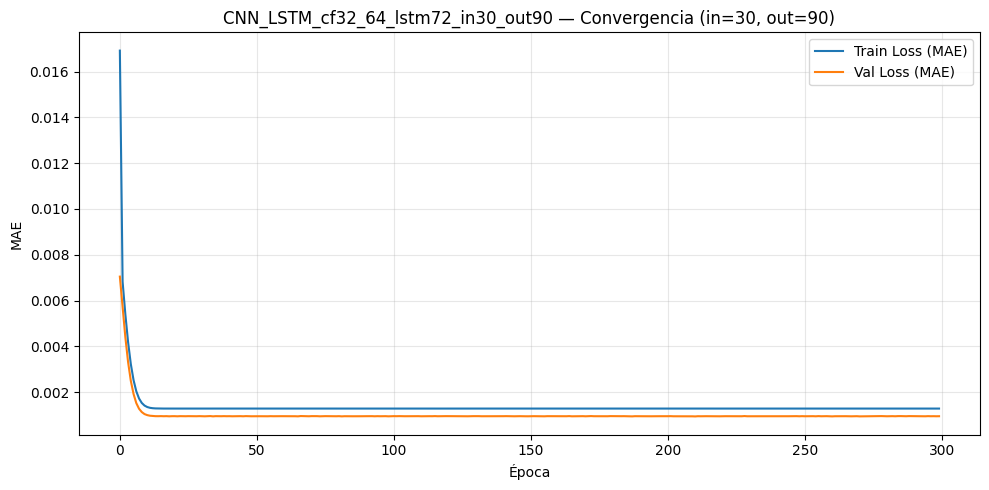

Modelo guardado en: models/CNN_LSTM_cf32_64_lstm72_in30_out90.keras


In [19]:
# ============================================================================
# ▶▶▶ CONFIGURACIÓN — CAMBIA AQUÍ LOS PARÁMETROS ◀◀◀
# ============================================================================

# --- Ventanas ---
INPUT_WINDOW  = 30
OUTPUT_WINDOW = 90
# --- Bloque convolucional ---
FILTERS_1     = 32          # Filtros primera Conv1D
KERNEL_SIZE_1 = 5           # Kernel primera Conv1D
FILTERS_2     = 64          # Filtros segunda Conv1D (0 para desactivar)
KERNEL_SIZE_2 = 3           # Kernel segunda Conv1D
PADDING       = 'same'      # Siempre 'same' para mantener resolución temporal
SPATIAL_DROP  = 0.1         # SpatialDropout1D tras cada conv (0 para desactivar)
USE_BATCHNORM = True        # BatchNormalization tras cada conv
L2_REG        = 0.0001      # Regularización L2 en capas conv (0 para desactivar)

# --- Bloque LSTM ---
LSTM_UNITS_1  = 72          # Unidades primera LSTM
LSTM_UNITS_2  = 0           # Unidades segunda LSTM (0 para desactivar)
LSTM_DROPOUT  = 0.1         # Dropout interno de la LSTM (recurrent_dropout)
LSTM_USE_GAP  = False       # True → GlobalAveragePooling sobre salida LSTM
                            # False → usa solo el último hidden state (por defecto)

# --- Bloque denso ---
DENSE_1       = 128          # Neuronas primera capa densa
DENSE_2       = 64          # Neuronas segunda capa densa (0 para desactivar)
DROPOUT_1     = 0.4         # Dropout tras primera densa
DROPOUT_2     = 0.5         # Dropout tras segunda densa

# --- Entrenamiento ---
LEARNING_RATE = 0.001
EPOCHS        = 300
BATCH_SIZE    = 64
MIN_DELTA     = 1e-5
VAL_SPLIT     = 0.1

# --- Nombre del modelo ---
MODEL_NAME = (
    f"CNN_LSTM"
    f"_cf{FILTERS_1}{'_'+str(FILTERS_2) if FILTERS_2 else ''}"
    f"_lstm{LSTM_UNITS_1}{'_'+str(LSTM_UNITS_2) if LSTM_UNITS_2 else ''}"
    f"_in{INPUT_WINDOW}_out{OUTPUT_WINDOW}"
)


# ============================================================================
# CONSTRUCCIÓN DEL MODELO
# ============================================================================

def build_cnn_lstm(input_window, n_features=23):

    reg = l2(L2_REG) if L2_REG > 0 else None

    inp = Input(shape=(input_window, n_features))
    x = inp

    # ── Bloque convolucional ──
    x = Conv1D(FILTERS_1, kernel_size=KERNEL_SIZE_1, padding=PADDING,
               activation='relu', kernel_regularizer=reg)(x)
    if USE_BATCHNORM:
        x = BatchNormalization()(x)
    if SPATIAL_DROP > 0:
        x = SpatialDropout1D(SPATIAL_DROP)(x)

    if FILTERS_2 > 0:
        x = Conv1D(FILTERS_2, kernel_size=KERNEL_SIZE_2, padding=PADDING,
                   activation='relu', kernel_regularizer=reg)(x)
        if USE_BATCHNORM:
            x = BatchNormalization()(x)
        if SPATIAL_DROP > 0:
            x = SpatialDropout1D(SPATIAL_DROP)(x)

    # En este punto: shape = (input_window, FILTERS_2 o FILTERS_1)
    # Es una secuencia temporal de features convolucionales → ideal para LSTM

    # ── Bloque LSTM ──
    return_sequences = (LSTM_UNITS_2 > 0) or LSTM_USE_GAP
    x = LSTM(
        LSTM_UNITS_1,
        return_sequences=return_sequences,
        dropout=LSTM_DROPOUT,
        recurrent_dropout=LSTM_DROPOUT
    )(x)

    if LSTM_UNITS_2 > 0:
        x = LSTM(
            LSTM_UNITS_2,
            return_sequences=LSTM_USE_GAP,
            dropout=LSTM_DROPOUT,
            recurrent_dropout=LSTM_DROPOUT
        )(x)

    if LSTM_USE_GAP:
        x = GlobalAveragePooling1D()(x)

    # ── Bloque denso ──
    x = Dense(DENSE_1, activation='relu')(x)
    if DROPOUT_1 > 0:
        x = Dropout(DROPOUT_1)(x)

    if DENSE_2 > 0:
        x = Dense(DENSE_2, activation='relu')(x)
        if DROPOUT_2 > 0:
            x = Dropout(DROPOUT_2)(x)

    # ── Salida ──
    out = Dense(n_features)(x)

    model = Model(inputs=inp, outputs=out)
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='mae'
    )
    return model


# ============================================================================
# CARGA DE DATOS
# ============================================================================

print("Cargando datos...")
returns = load_data()

X_train, X_test, y_train, y_test = get_train_test(returns, INPUT_WINDOW, OUTPUT_WINDOW)

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}   y_test:  {y_test.shape}")

# Validación temporal (último 10% del train, sin shuffle)
split_idx = int(len(X_train) * (1 - VAL_SPLIT))
X_tr,  y_tr  = X_train[:split_idx], y_train[:split_idx]
X_val, y_val = X_train[split_idx:], y_train[split_idx:]

print(f"Train:   {X_tr.shape}  Val: {X_val.shape}")


# ============================================================================
# CONSTRUCCIÓN E INSPECCIÓN
# ============================================================================

model = build_cnn_lstm(INPUT_WINDOW, n_features=X_train.shape[2])
n_params = count_parameters(model)

print(f"\n{'='*60}")
print(f"  Modelo: {MODEL_NAME}")
print(f"  Parámetros: {n_params:,}")
print(f"{'='*60}")
model.summary()


# ============================================================================
# ENTRENAMIENTO
# ============================================================================


history = model.fit(
    X_tr, y_tr,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),   # validación temporal, sin shuffle
    shuffle=True,                      # shuffle dentro del train está ok
    verbose=1
)

print(f"\nEntrenamiento detenido en la época {len(history.history['loss'])}")


# ============================================================================
# EVALUACIÓN
# ============================================================================

y_pred_train = model.predict(X_train, verbose=0)
y_pred_test  = model.predict(X_test, verbose=0)
y_pred_val   = model.predict(X_val, verbose=0)

mae_train = compute_mae(y_train, y_pred_train)
mae_val   = compute_mae(y_val, y_pred_val)
mae_test  = compute_mae(y_test, y_pred_test)

# Baseline: predecir cero
mae_zero = np.mean(np.abs(y_test))

print(f"\n{'='*60}")
print(f"  Resultados {MODEL_NAME}:")
print(f"    MAE Train:    {mae_train:.6f}")
print(f"    MAE Val:      {mae_val:.6f}")
print(f"    MAE Test:     {mae_test:.6f}")
print(f"    MAE Zero:     {mae_zero:.6f}  (baseline: predecir 0)")
print(f"    Mejora vs 0:  {(mae_zero - mae_test) / mae_zero * 100:.2f}%")
print(f"{'='*60}")

# Comprobar si el modelo predice algo o está "muerto"
y_pred_std = np.std(y_pred_test)
print(f"\n  Diagnóstico:")
print(f"    Std predicciones test: {y_pred_std:.6f}")
if y_pred_std < 1e-4:
    print("    ⚠️  Las predicciones tienen varianza ~0: el modelo predice constante.")
    print("    → Revisa el planteamiento (loss, features, target).")
else:
    print("    ✓  Las predicciones tienen varianza razonable.")


# ============================================================================
# GUARDAR RESULTADOS
# ============================================================================

save_results(
    model_name=MODEL_NAME,
    model_type='cnn_lstm',
    input_window=INPUT_WINDOW,
    output_window=OUTPUT_WINDOW,
    mae_train=mae_train,
    mae_test=mae_test,
    n_params=n_params,
    mae_val=mae_val
)

plot_training_curves(history, MODEL_NAME, INPUT_WINDOW, OUTPUT_WINDOW, save=True)

model_path = os.path.join(MODELS_DIR, f"{MODEL_NAME}.keras")
model.save(model_path)
print(f"Modelo guardado en: {model_path}")

Cargando datos...


[*********************100%***********************]  23 of 23 completed


Datos cargados: 16191 días, 23 activos
Rango: 1962-01-03 → 2026-05-04
Ventana entrada=30, salida=5
  X_train: (14541, 30, 23) | y_train: (14541, 23)
  X_test:  (1616, 30, 23)  | y_test:  (1616, 23)
X_train: (14541, 30, 23)  y_train: (14541, 23)
X_test:  (1616, 30, 23)   y_test:  (1616, 23)
Train:   (13086, 30, 23)  Val: (1455, 30, 23)

  Modelo: CNN_LSTM_cf32_64_lstm60_in30_out5
  Parámetros: 46,855


Model: "functional_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_21 (InputLayer)     │ (None, 30, 23)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_32 (Conv1D)              │ (None, 30, 32)         │         3,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 30, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_15            │ (None, 30, 32)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_33 (Conv1D)              │ (None, 30, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 30, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_16            │ (None, 30, 64)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_21 (LSTM)                  │ (None, 60)             │        30,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 64)             │         3,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_62 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_63 (Dense)                │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,047 (183.78 KB)

 Trainable params: 46,855 (183.03 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/300
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.1321 - val_loss: 0.0422
Epoch 2/300
205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1069 - val_loss: 0.0563
Epoch 3/300
205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0881 - val_loss: 0.0364
Epoch 4/300
205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0744 - val_loss: 0.0241
Epoch 5/300
205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0628 - val_loss: 0.0202
Epoch 6/300
205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0543 - val_loss: 0.0166
Epoch 7/300
205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0470 - val_loss: 0.0141
Epoch 8/300
205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0406 - val_loss: 0.0122
Epoch 9/300
205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0355 - val_loss: 0.0109
Epoch 10/300
205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0311 - val_loss: 0.0099
Epoch 11/300
205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0274 - val_loss: 0.0091
Epoch 12/300
205/205 ━━━━━━━━━━━━━━━━━━━━

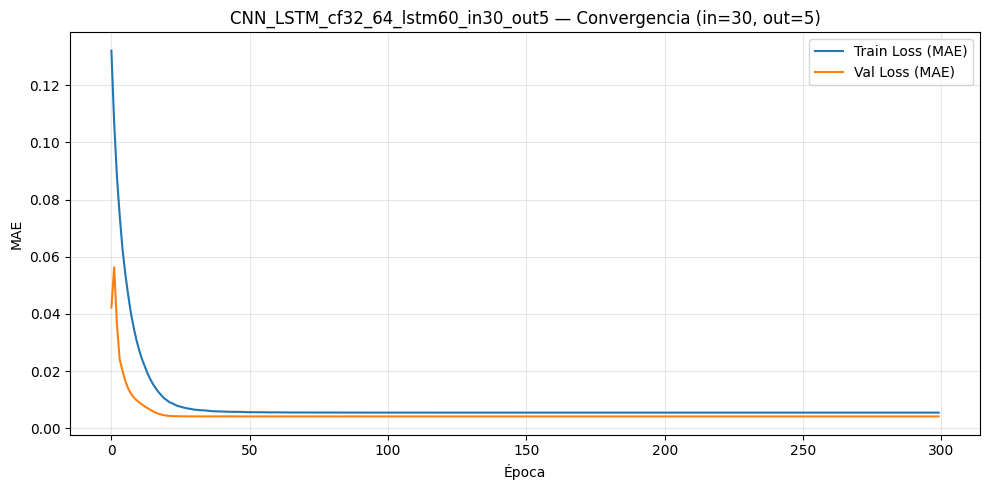

Modelo guardado en: models/CNN_LSTM_cf32_64_lstm60_in30_out5.keras


In [22]:
# ============================================================================
# ▶▶▶ CONFIGURACIÓN — CAMBIA AQUÍ LOS PARÁMETROS ◀◀◀
# ============================================================================

# --- Ventanas ---
INPUT_WINDOW  = 30
OUTPUT_WINDOW = 5
# --- Bloque convolucional ---
FILTERS_1     = 32          # Filtros primera Conv1D
KERNEL_SIZE_1 = 5           # Kernel primera Conv1D
FILTERS_2     = 64          # Filtros segunda Conv1D (0 para desactivar)
KERNEL_SIZE_2 = 3           # Kernel segunda Conv1D
PADDING       = 'same'      # Siempre 'same' para mantener resolución temporal
SPATIAL_DROP  = 0.1         # SpatialDropout1D tras cada conv (0 para desactivar)
USE_BATCHNORM = True        # BatchNormalization tras cada conv
L2_REG        = 0.000      # Regularización L2 en capas conv (0 para desactivar)

# --- Bloque LSTM ---
LSTM_UNITS_1  = 60          # Unidades primera LSTM
LSTM_UNITS_2  = 0           # Unidades segunda LSTM (0 para desactivar)
LSTM_DROPOUT  = 0.0         # Dropout interno de la LSTM (recurrent_dropout)
LSTM_USE_GAP  = False       # True → GlobalAveragePooling sobre salida LSTM
                            # False → usa solo el último hidden state (por defecto)

# --- Bloque denso ---
DENSE_1       = 64          # Neuronas primera capa densa
DENSE_2       = 32          # Neuronas segunda capa densa (0 para desactivar)
DROPOUT_1     = 0.3         # Dropout tras primera densa
DROPOUT_2     = 0.4         # Dropout tras segunda densa

# --- Entrenamiento ---
LEARNING_RATE = 0.00001
EPOCHS        = 300
BATCH_SIZE    = 64
MIN_DELTA     = 1e-5
VAL_SPLIT     = 0.1

# --- Nombre del modelo ---
MODEL_NAME = (
    f"CNN_LSTM"
    f"_cf{FILTERS_1}{'_'+str(FILTERS_2) if FILTERS_2 else ''}"
    f"_lstm{LSTM_UNITS_1}{'_'+str(LSTM_UNITS_2) if LSTM_UNITS_2 else ''}"
    f"_in{INPUT_WINDOW}_out{OUTPUT_WINDOW}"
)


# ============================================================================
# CONSTRUCCIÓN DEL MODELO
# ============================================================================

def build_cnn_lstm(input_window, n_features=23):

    reg = l2(L2_REG) if L2_REG > 0 else None

    inp = Input(shape=(input_window, n_features))
    x = inp

    # ── Bloque convolucional ──
    x = Conv1D(FILTERS_1, kernel_size=KERNEL_SIZE_1, padding=PADDING,
               activation='relu', kernel_regularizer=reg)(x)
    if USE_BATCHNORM:
        x = BatchNormalization()(x)
    if SPATIAL_DROP > 0:
        x = SpatialDropout1D(SPATIAL_DROP)(x)

    if FILTERS_2 > 0:
        x = Conv1D(FILTERS_2, kernel_size=KERNEL_SIZE_2, padding=PADDING,
                   activation='relu', kernel_regularizer=reg)(x)
        if USE_BATCHNORM:
            x = BatchNormalization()(x)
        if SPATIAL_DROP > 0:
            x = SpatialDropout1D(SPATIAL_DROP)(x)

    # En este punto: shape = (input_window, FILTERS_2 o FILTERS_1)
    # Es una secuencia temporal de features convolucionales → ideal para LSTM

    # ── Bloque LSTM ──
    return_sequences = (LSTM_UNITS_2 > 0) or LSTM_USE_GAP
    x = LSTM(
        LSTM_UNITS_1,
        return_sequences=return_sequences,
        dropout=LSTM_DROPOUT,
        recurrent_dropout=LSTM_DROPOUT
    )(x)

    if LSTM_UNITS_2 > 0:
        x = LSTM(
            LSTM_UNITS_2,
            return_sequences=LSTM_USE_GAP,
            dropout=LSTM_DROPOUT,
            recurrent_dropout=LSTM_DROPOUT
        )(x)

    if LSTM_USE_GAP:
        x = GlobalAveragePooling1D()(x)

    # ── Bloque denso ──
    x = Dense(DENSE_1, activation='relu')(x)
    if DROPOUT_1 > 0:
        x = Dropout(DROPOUT_1)(x)

    if DENSE_2 > 0:
        x = Dense(DENSE_2, activation='relu')(x)
        if DROPOUT_2 > 0:
            x = Dropout(DROPOUT_2)(x)

    # ── Salida ──
    out = Dense(n_features)(x)

    model = Model(inputs=inp, outputs=out)
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='mae'
    )
    return model


# ============================================================================
# CARGA DE DATOS
# ============================================================================

print("Cargando datos...")
returns = load_data()

X_train, X_test, y_train, y_test = get_train_test(returns, INPUT_WINDOW, OUTPUT_WINDOW)

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}   y_test:  {y_test.shape}")

# Validación temporal (último 10% del train, sin shuffle)
split_idx = int(len(X_train) * (1 - VAL_SPLIT))
X_tr,  y_tr  = X_train[:split_idx], y_train[:split_idx]
X_val, y_val = X_train[split_idx:], y_train[split_idx:]

print(f"Train:   {X_tr.shape}  Val: {X_val.shape}")


# ============================================================================
# CONSTRUCCIÓN E INSPECCIÓN
# ============================================================================

model = build_cnn_lstm(INPUT_WINDOW, n_features=X_train.shape[2])
n_params = count_parameters(model)

print(f"\n{'='*60}")
print(f"  Modelo: {MODEL_NAME}")
print(f"  Parámetros: {n_params:,}")
print(f"{'='*60}")
model.summary()


# ============================================================================
# ENTRENAMIENTO
# ============================================================================


history = model.fit(
    X_tr, y_tr,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),   # validación temporal, sin shuffle
    shuffle=True,                      # shuffle dentro del train está ok
    verbose=1
)

print(f"\nEntrenamiento detenido en la época {len(history.history['loss'])}")


# ============================================================================
# EVALUACIÓN
# ============================================================================

y_pred_train = model.predict(X_train, verbose=0)
y_pred_test  = model.predict(X_test, verbose=0)
y_pred_val   = model.predict(X_val, verbose=0)

mae_train = compute_mae(y_train, y_pred_train)
mae_val   = compute_mae(y_val, y_pred_val)
mae_test  = compute_mae(y_test, y_pred_test)

# Baseline: predecir cero
mae_zero = np.mean(np.abs(y_test))

print(f"\n{'='*60}")
print(f"  Resultados {MODEL_NAME}:")
print(f"    MAE Train:    {mae_train:.6f}")
print(f"    MAE Val:      {mae_val:.6f}")
print(f"    MAE Test:     {mae_test:.6f}")
print(f"    MAE Zero:     {mae_zero:.6f}  (baseline: predecir 0)")
print(f"    Mejora vs 0:  {(mae_zero - mae_test) / mae_zero * 100:.2f}%")
print(f"{'='*60}")

# Comprobar si el modelo predice algo o está "muerto"
y_pred_std = np.std(y_pred_test)
print(f"\n  Diagnóstico:")
print(f"    Std predicciones test: {y_pred_std:.6f}")
if y_pred_std < 1e-4:
    print("    ⚠️  Las predicciones tienen varianza ~0: el modelo predice constante.")
    print("    → Revisa el planteamiento (loss, features, target).")
else:
    print("    ✓  Las predicciones tienen varianza razonable.")


# ============================================================================
# GUARDAR RESULTADOS
# ============================================================================

save_results(
    model_name=MODEL_NAME,
    model_type='cnn_lstm',
    input_window=INPUT_WINDOW,
    output_window=OUTPUT_WINDOW,
    mae_train=mae_train,
    mae_test=mae_test,
    n_params=n_params,
    mae_val=mae_val
)

plot_training_curves(history, MODEL_NAME, INPUT_WINDOW, OUTPUT_WINDOW, save=True)

model_path = os.path.join(MODELS_DIR, f"{MODEL_NAME}.keras")
model.save(model_path)
print(f"Modelo guardado en: {model_path}")

Cargando datos...


[*********************100%***********************]  23 of 23 completed


Datos cargados: 16191 días, 23 activos
Rango: 1962-01-03 → 2026-05-04
Ventana entrada=30, salida=5
  X_train: (14541, 30, 23) | y_train: (14541, 23)
  X_test:  (1616, 30, 23)  | y_test:  (1616, 23)
X_train: (14541, 30, 23)  y_train: (14541, 23)
X_test:  (1616, 30, 23)   y_test:  (1616, 23)
Train:   (13086, 30, 23)  Val: (1455, 30, 23)

  Modelo: CNN_LSTM_cf32_64_lstm60_in30_out5
  Parámetros: 46,855


Model: "functional_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_22 (InputLayer)     │ (None, 30, 23)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_34 (Conv1D)              │ (None, 30, 32)         │         3,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 30, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_17            │ (None, 30, 32)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_35 (Conv1D)              │ (None, 30, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 30, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_18            │ (None, 30, 64)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_22 (LSTM)                  │ (None, 60)             │        30,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │         3,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_65 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_66 (Dense)                │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,047 (183.78 KB)

 Trainable params: 46,855 (183.03 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/300
205/205 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0196 - val_loss: 0.0104
Epoch 2/300
205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0111 - val_loss: 0.0091
Epoch 3/300
205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0098 - val_loss: 0.0078
Epoch 4/300
205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0086 - val_loss: 0.0067
Epoch 5/300
205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0076 - val_loss: 0.0058
Epoch 6/300
205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0068 - val_loss: 0.0052
Epoch 7/300
205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0063 - val_loss: 0.0048
Epoch 8/300
205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0060 - val_loss: 0.0045
Epoch 9/300
205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0058 - val_loss: 0.0044
Epoch 10/300
205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0056 - val_loss: 0.0043
Epoch 11/300
205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0056 - val_loss: 0.0042
Epoch 12/300
205/205 ━━━━━━━━━

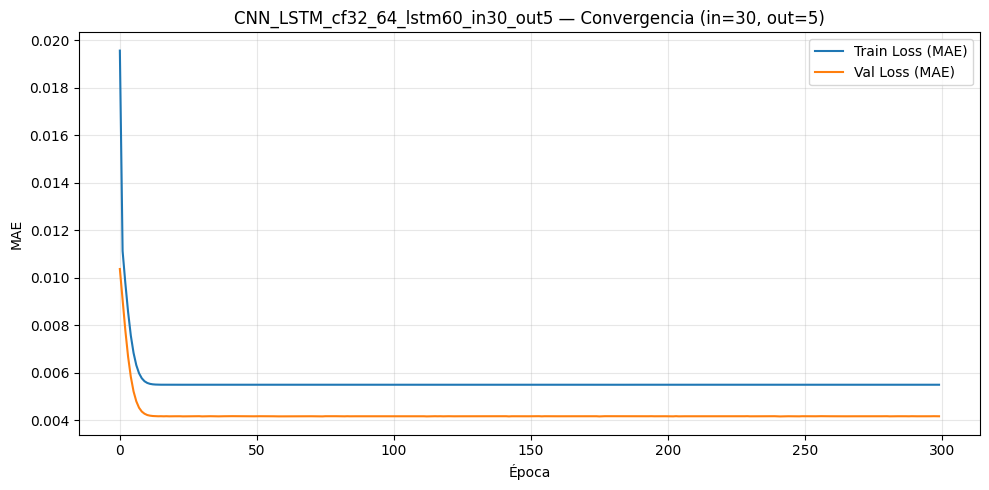

Modelo guardado en: models/CNN_LSTM_cf32_64_lstm60_in30_out5.keras


In [23]:
# ============================================================================
# ▶▶▶ CONFIGURACIÓN — CAMBIA AQUÍ LOS PARÁMETROS ◀◀◀
# ============================================================================

# --- Ventanas ---
INPUT_WINDOW  = 30
OUTPUT_WINDOW = 5
# --- Bloque convolucional ---
FILTERS_1     = 32          # Filtros primera Conv1D
KERNEL_SIZE_1 = 5           # Kernel primera Conv1D
FILTERS_2     = 64          # Filtros segunda Conv1D (0 para desactivar)
KERNEL_SIZE_2 = 3           # Kernel segunda Conv1D
PADDING       = 'same'      # Siempre 'same' para mantener resolución temporal
SPATIAL_DROP  = 0.1         # SpatialDropout1D tras cada conv (0 para desactivar)
USE_BATCHNORM = True        # BatchNormalization tras cada conv
L2_REG        = 0.0001      # Regularización L2 en capas conv (0 para desactivar)

# --- Bloque LSTM ---
LSTM_UNITS_1  = 60          # Unidades primera LSTM
LSTM_UNITS_2  = 0           # Unidades segunda LSTM (0 para desactivar)
LSTM_DROPOUT  = 0.1         # Dropout interno de la LSTM (recurrent_dropout)
LSTM_USE_GAP  = False       # True → GlobalAveragePooling sobre salida LSTM
                            # False → usa solo el último hidden state (por defecto)

# --- Bloque denso ---
DENSE_1       = 64          # Neuronas primera capa densa
DENSE_2       = 32          # Neuronas segunda capa densa (0 para desactivar)
DROPOUT_1     = 0.3         # Dropout tras primera densa
DROPOUT_2     = 0.4         # Dropout tras segunda densa

# --- Entrenamiento ---
LEARNING_RATE = 0.001
EPOCHS        = 300
BATCH_SIZE    = 64
MIN_DELTA     = 1e-5
VAL_SPLIT     = 0.1

# --- Nombre del modelo ---
MODEL_NAME = (
    f"CNN_LSTM"
    f"_cf{FILTERS_1}{'_'+str(FILTERS_2) if FILTERS_2 else ''}"
    f"_lstm{LSTM_UNITS_1}{'_'+str(LSTM_UNITS_2) if LSTM_UNITS_2 else ''}"
    f"_in{INPUT_WINDOW}_out{OUTPUT_WINDOW}"
)


# ============================================================================
# CONSTRUCCIÓN DEL MODELO
# ============================================================================

def build_cnn_lstm(input_window, n_features=23):

    reg = l2(L2_REG) if L2_REG > 0 else None

    inp = Input(shape=(input_window, n_features))
    x = inp

    # ── Bloque convolucional ──
    x = Conv1D(FILTERS_1, kernel_size=KERNEL_SIZE_1, padding=PADDING,
               activation='relu', kernel_regularizer=reg)(x)
    if USE_BATCHNORM:
        x = BatchNormalization()(x)
    if SPATIAL_DROP > 0:
        x = SpatialDropout1D(SPATIAL_DROP)(x)

    if FILTERS_2 > 0:
        x = Conv1D(FILTERS_2, kernel_size=KERNEL_SIZE_2, padding=PADDING,
                   activation='relu', kernel_regularizer=reg)(x)
        if USE_BATCHNORM:
            x = BatchNormalization()(x)
        if SPATIAL_DROP > 0:
            x = SpatialDropout1D(SPATIAL_DROP)(x)

    # En este punto: shape = (input_window, FILTERS_2 o FILTERS_1)
    # Es una secuencia temporal de features convolucionales → ideal para LSTM

    # ── Bloque LSTM ──
    return_sequences = (LSTM_UNITS_2 > 0) or LSTM_USE_GAP
    x = LSTM(
        LSTM_UNITS_1,
        return_sequences=return_sequences,
        dropout=LSTM_DROPOUT,
        recurrent_dropout=LSTM_DROPOUT
    )(x)

    if LSTM_UNITS_2 > 0:
        x = LSTM(
            LSTM_UNITS_2,
            return_sequences=LSTM_USE_GAP,
            dropout=LSTM_DROPOUT,
            recurrent_dropout=LSTM_DROPOUT
        )(x)

    if LSTM_USE_GAP:
        x = GlobalAveragePooling1D()(x)

    # ── Bloque denso ──
    x = Dense(DENSE_1, activation='relu')(x)
    if DROPOUT_1 > 0:
        x = Dropout(DROPOUT_1)(x)

    if DENSE_2 > 0:
        x = Dense(DENSE_2, activation='relu')(x)
        if DROPOUT_2 > 0:
            x = Dropout(DROPOUT_2)(x)

    # ── Salida ──
    out = Dense(n_features)(x)

    model = Model(inputs=inp, outputs=out)
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='mae'
    )
    return model


# ============================================================================
# CARGA DE DATOS
# ============================================================================

print("Cargando datos...")
returns = load_data()

X_train, X_test, y_train, y_test = get_train_test(returns, INPUT_WINDOW, OUTPUT_WINDOW)

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}   y_test:  {y_test.shape}")

# Validación temporal (último 10% del train, sin shuffle)
split_idx = int(len(X_train) * (1 - VAL_SPLIT))
X_tr,  y_tr  = X_train[:split_idx], y_train[:split_idx]
X_val, y_val = X_train[split_idx:], y_train[split_idx:]

print(f"Train:   {X_tr.shape}  Val: {X_val.shape}")


# ============================================================================
# CONSTRUCCIÓN E INSPECCIÓN
# ============================================================================

model = build_cnn_lstm(INPUT_WINDOW, n_features=X_train.shape[2])
n_params = count_parameters(model)

print(f"\n{'='*60}")
print(f"  Modelo: {MODEL_NAME}")
print(f"  Parámetros: {n_params:,}")
print(f"{'='*60}")
model.summary()


# ============================================================================
# ENTRENAMIENTO
# ============================================================================


history = model.fit(
    X_tr, y_tr,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),   # validación temporal, sin shuffle
    shuffle=True,                      # shuffle dentro del train está ok
    verbose=1
)

print(f"\nEntrenamiento detenido en la época {len(history.history['loss'])}")


# ============================================================================
# EVALUACIÓN
# ============================================================================

y_pred_train = model.predict(X_train, verbose=0)
y_pred_test  = model.predict(X_test, verbose=0)
y_pred_val   = model.predict(X_val, verbose=0)

mae_train = compute_mae(y_train, y_pred_train)
mae_val   = compute_mae(y_val, y_pred_val)
mae_test  = compute_mae(y_test, y_pred_test)

# Baseline: predecir cero
mae_zero = np.mean(np.abs(y_test))

print(f"\n{'='*60}")
print(f"  Resultados {MODEL_NAME}:")
print(f"    MAE Train:    {mae_train:.6f}")
print(f"    MAE Val:      {mae_val:.6f}")
print(f"    MAE Test:     {mae_test:.6f}")
print(f"    MAE Zero:     {mae_zero:.6f}  (baseline: predecir 0)")
print(f"    Mejora vs 0:  {(mae_zero - mae_test) / mae_zero * 100:.2f}%")
print(f"{'='*60}")

# Comprobar si el modelo predice algo o está "muerto"
y_pred_std = np.std(y_pred_test)
print(f"\n  Diagnóstico:")
print(f"    Std predicciones test: {y_pred_std:.6f}")
if y_pred_std < 1e-4:
    print("    ⚠️  Las predicciones tienen varianza ~0: el modelo predice constante.")
    print("    → Revisa el planteamiento (loss, features, target).")
else:
    print("    ✓  Las predicciones tienen varianza razonable.")


# ============================================================================
# GUARDAR RESULTADOS
# ============================================================================

save_results(
    model_name=MODEL_NAME,
    model_type='cnn_lstm',
    input_window=INPUT_WINDOW,
    output_window=OUTPUT_WINDOW,
    mae_train=mae_train,
    mae_test=mae_test,
    n_params=n_params,
    mae_val=mae_val
)

plot_training_curves(history, MODEL_NAME, INPUT_WINDOW, OUTPUT_WINDOW, save=True)

model_path = os.path.join(MODELS_DIR, f"{MODEL_NAME}.keras")
model.save(model_path)
print(f"Modelo guardado en: {model_path}")

Cargando datos...


[*********************100%***********************]  23 of 23 completed


Datos cargados: 16191 días, 23 activos
Rango: 1962-01-03 → 2026-05-04
Ventana entrada=30, salida=1
  X_train: (14544, 30, 23) | y_train: (14544, 23)
  X_test:  (1617, 30, 23)  | y_test:  (1617, 23)
X_train: (14544, 30, 23)  y_train: (14544, 23)
X_test:  (1617, 30, 23)   y_test:  (1617, 23)
Train:   (13089, 30, 23)  Val: (1455, 30, 23)

  Modelo: CNN_LSTM_cf32_64_lstm48_in30_out1
  Parámetros: 35,671


Model: "functional_26"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_26 (InputLayer)     │ (None, 30, 23)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_42 (Conv1D)              │ (None, 30, 32)         │         3,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_42          │ (None, 30, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_25            │ (None, 30, 32)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_43 (Conv1D)              │ (None, 30, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_43          │ (None, 30, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_26            │ (None, 30, 64)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_26 (LSTM)                  │ (None, 48)             │        21,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_74 (Dense)                │ (None, 64)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_42 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_75 (Dense)                │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_43 (Dropout)            │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_76 (Dense)                │ (None, 23)             │           207 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,863 (140.09 KB)

 Trainable params: 35,671 (139.34 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/300
819/819 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.0301 - val_loss: 0.0159
Epoch 2/300
819/819 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0193 - val_loss: 0.0157
Epoch 3/300
819/819 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0186 - val_loss: 0.0154
Epoch 4/300
819/819 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0182 - val_loss: 0.0151
Epoch 5/300
819/819 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0177 - val_loss: 0.0146
Epoch 6/300
819/819 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0171 - val_loss: 0.0140
Epoch 7/300
819/819 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0164 - val_loss: 0.0132
Epoch 8/300
819/819 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0157 - val_loss: 0.0125
Epoch 9/300
819/819 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0148 - val_loss: 0.0117
Epoch 10/300
819/819 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0141 - val_loss: 0.0110
Epoch 11/300
819/819 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0135 - val_loss: 0.0104
Epoch 12/300
819/819 ━━━━━━━━━━━━━━━━━━━

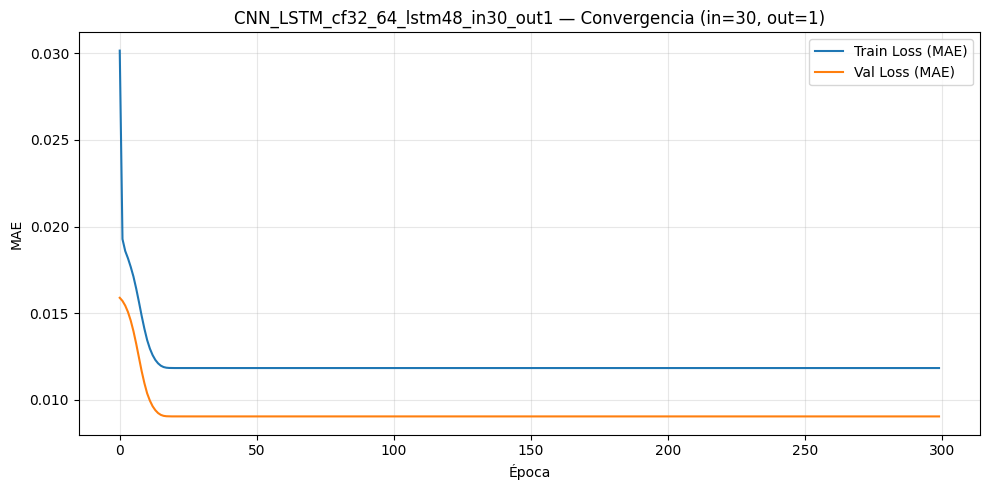

Modelo guardado en: models/CNN_LSTM_cf32_64_lstm48_in30_out1.keras


In [27]:
# ============================================================================
# ▶▶▶ CONFIGURACIÓN — CAMBIA AQUÍ LOS PARÁMETROS ◀◀◀
# ============================================================================

# --- Ventanas ---
INPUT_WINDOW  = 30
OUTPUT_WINDOW = 1
# --- Bloque convolucional ---
FILTERS_1     = 32          # Filtros primera Conv1D
KERNEL_SIZE_1 = 5           # Kernel primera Conv1D
FILTERS_2     = 64          # Filtros segunda Conv1D (0 para desactivar)
KERNEL_SIZE_2 = 3           # Kernel segunda Conv1D
PADDING       = 'same'      # Siempre 'same' para mantener resolución temporal
SPATIAL_DROP  = 0.1         # SpatialDropout1D tras cada conv (0 para desactivar)
USE_BATCHNORM = True        # BatchNormalization tras cada conv
L2_REG        = 0.0001      # Regularización L2 en capas conv (0 para desactivar)

# --- Bloque LSTM ---
LSTM_UNITS_1  = 48          # Unidades primera LSTM
LSTM_UNITS_2  = 0           # Unidades segunda LSTM (0 para desactivar)
LSTM_DROPOUT  = 0.1         # Dropout interno de la LSTM (recurrent_dropout)
LSTM_USE_GAP  = False       # True → GlobalAveragePooling sobre salida LSTM
                            # False → usa solo el último hidden state (por defecto)

# --- Bloque denso ---
DENSE_1       = 64          # Neuronas primera capa densa
DENSE_2       = 8          # Neuronas segunda capa densa (0 para desactivar)
DROPOUT_1     = 0.3         # Dropout tras primera densa
DROPOUT_2     = 0.4         # Dropout tras segunda densa

# --- Entrenamiento ---
LEARNING_RATE = 0.0001
EPOCHS        = 300
BATCH_SIZE    = 16
MIN_DELTA     = 1e-5
VAL_SPLIT     = 0.1

# --- Nombre del modelo ---
MODEL_NAME = (
    f"CNN_LSTM"
    f"_cf{FILTERS_1}{'_'+str(FILTERS_2) if FILTERS_2 else ''}"
    f"_lstm{LSTM_UNITS_1}{'_'+str(LSTM_UNITS_2) if LSTM_UNITS_2 else ''}"
    f"_in{INPUT_WINDOW}_out{OUTPUT_WINDOW}"
)


# ============================================================================
# CONSTRUCCIÓN DEL MODELO
# ============================================================================

def build_cnn_lstm(input_window, n_features=23):

    reg = l2(L2_REG) if L2_REG > 0 else None

    inp = Input(shape=(input_window, n_features))
    x = inp

    # ── Bloque convolucional ──
    x = Conv1D(FILTERS_1, kernel_size=KERNEL_SIZE_1, padding=PADDING,
               activation='relu', kernel_regularizer=reg)(x)
    if USE_BATCHNORM:
        x = BatchNormalization()(x)
    if SPATIAL_DROP > 0:
        x = SpatialDropout1D(SPATIAL_DROP)(x)

    if FILTERS_2 > 0:
        x = Conv1D(FILTERS_2, kernel_size=KERNEL_SIZE_2, padding=PADDING,
                   activation='relu', kernel_regularizer=reg)(x)
        if USE_BATCHNORM:
            x = BatchNormalization()(x)
        if SPATIAL_DROP > 0:
            x = SpatialDropout1D(SPATIAL_DROP)(x)

    # En este punto: shape = (input_window, FILTERS_2 o FILTERS_1)
    # Es una secuencia temporal de features convolucionales → ideal para LSTM

    # ── Bloque LSTM ──
    return_sequences = (LSTM_UNITS_2 > 0) or LSTM_USE_GAP
    x = LSTM(
        LSTM_UNITS_1,
        return_sequences=return_sequences,
        dropout=LSTM_DROPOUT,
        recurrent_dropout=LSTM_DROPOUT
    )(x)

    if LSTM_UNITS_2 > 0:
        x = LSTM(
            LSTM_UNITS_2,
            return_sequences=LSTM_USE_GAP,
            dropout=LSTM_DROPOUT,
            recurrent_dropout=LSTM_DROPOUT
        )(x)

    if LSTM_USE_GAP:
        x = GlobalAveragePooling1D()(x)

    # ── Bloque denso ──
    x = Dense(DENSE_1, activation='relu')(x)
    if DROPOUT_1 > 0:
        x = Dropout(DROPOUT_1)(x)

    if DENSE_2 > 0:
        x = Dense(DENSE_2, activation='relu')(x)
        if DROPOUT_2 > 0:
            x = Dropout(DROPOUT_2)(x)

    # ── Salida ──
    out = Dense(n_features)(x)

    model = Model(inputs=inp, outputs=out)
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='mae'
    )
    return model


# ============================================================================
# CARGA DE DATOS
# ============================================================================

print("Cargando datos...")
returns = load_data()

X_train, X_test, y_train, y_test = get_train_test(returns, INPUT_WINDOW, OUTPUT_WINDOW)

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}   y_test:  {y_test.shape}")

# Validación temporal (último 10% del train, sin shuffle)
split_idx = int(len(X_train) * (1 - VAL_SPLIT))
X_tr,  y_tr  = X_train[:split_idx], y_train[:split_idx]
X_val, y_val = X_train[split_idx:], y_train[split_idx:]

print(f"Train:   {X_tr.shape}  Val: {X_val.shape}")


# ============================================================================
# CONSTRUCCIÓN E INSPECCIÓN
# ============================================================================

model = build_cnn_lstm(INPUT_WINDOW, n_features=X_train.shape[2])
n_params = count_parameters(model)

print(f"\n{'='*60}")
print(f"  Modelo: {MODEL_NAME}")
print(f"  Parámetros: {n_params:,}")
print(f"{'='*60}")
model.summary()


# ============================================================================
# ENTRENAMIENTO
# ============================================================================


history = model.fit(
    X_tr, y_tr,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),   # validación temporal, sin shuffle
    shuffle=True,                      # shuffle dentro del train está ok
    verbose=1
)

print(f"\nEntrenamiento detenido en la época {len(history.history['loss'])}")


# ============================================================================
# EVALUACIÓN
# ============================================================================

y_pred_train = model.predict(X_train, verbose=0)
y_pred_test  = model.predict(X_test, verbose=0)
y_pred_val   = model.predict(X_val, verbose=0)

mae_train = compute_mae(y_train, y_pred_train)
mae_val   = compute_mae(y_val, y_pred_val)
mae_test  = compute_mae(y_test, y_pred_test)

# Baseline: predecir cero
mae_zero = np.mean(np.abs(y_test))

print(f"\n{'='*60}")
print(f"  Resultados {MODEL_NAME}:")
print(f"    MAE Train:    {mae_train:.6f}")
print(f"    MAE Val:      {mae_val:.6f}")
print(f"    MAE Test:     {mae_test:.6f}")
print(f"    MAE Zero:     {mae_zero:.6f}  (baseline: predecir 0)")
print(f"    Mejora vs 0:  {(mae_zero - mae_test) / mae_zero * 100:.2f}%")
print(f"{'='*60}")

# Comprobar si el modelo predice algo o está "muerto"
y_pred_std = np.std(y_pred_test)
print(f"\n  Diagnóstico:")
print(f"    Std predicciones test: {y_pred_std:.6f}")
if y_pred_std < 1e-4:
    print("    ⚠️  Las predicciones tienen varianza ~0: el modelo predice constante.")
    print("    → Revisa el planteamiento (loss, features, target).")
else:
    print("    ✓  Las predicciones tienen varianza razonable.")


# ============================================================================
# GUARDAR RESULTADOS
# ============================================================================

save_results(
    model_name=MODEL_NAME,
    model_type='cnn_lstm',
    input_window=INPUT_WINDOW,
    output_window=OUTPUT_WINDOW,
    mae_train=mae_train,
    mae_test=mae_test,
    n_params=n_params,
    mae_val=mae_val
)

plot_training_curves(history, MODEL_NAME, INPUT_WINDOW, OUTPUT_WINDOW, save=True)

model_path = os.path.join(MODELS_DIR, f"{MODEL_NAME}.keras")
model.save(model_path)
print(f"Modelo guardado en: {model_path}")

Cargando datos...


[*********************100%***********************]  23 of 23 completed


Datos cargados: 16191 días, 23 activos
Rango: 1962-01-03 → 2026-05-04
Ventana entrada=90, salida=90
  X_train: (14410, 90, 23) | y_train: (14410, 23)
  X_test:  (1602, 90, 23)  | y_test:  (1602, 23)
X_train: (14410, 90, 23)  y_train: (14410, 23)
X_test:  (1602, 90, 23)   y_test:  (1602, 23)
Train:   (12969, 90, 23)  Val: (1441, 90, 23)

  Modelo: CNN_LSTM_cf32_64_lstm96_48_in90_out90
  Parámetros: 115,799


Model: "functional_27"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_27 (InputLayer)     │ (None, 90, 23)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_44 (Conv1D)              │ (None, 90, 32)         │         3,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_44          │ (None, 90, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_27            │ (None, 90, 32)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_45 (Conv1D)              │ (None, 90, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_45          │ (None, 90, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_28            │ (None, 90, 64)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_27 (LSTM)                  │ (None, 90, 96)         │        61,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_28 (LSTM)                  │ (None, 48)             │        27,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_77 (Dense)                │ (None, 128)            │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_44 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_78 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_45 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_79 (Dense)                │ (None, 23)             │         1,495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 115,991 (453.09 KB)

 Trainable params: 115,799 (452.34 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/300
203/203 ━━━━━━━━━━━━━━━━━━━━ 16s 61ms/step - loss: 0.0107 - val_loss: 0.0061
Epoch 2/300
203/203 ━━━━━━━━━━━━━━━━━━━━ 12s 61ms/step - loss: 0.0053 - val_loss: 0.0039
Epoch 3/300
203/203 ━━━━━━━━━━━━━━━━━━━━ 12s 61ms/step - loss: 0.0034 - val_loss: 0.0024
Epoch 4/300
203/203 ━━━━━━━━━━━━━━━━━━━━ 12s 61ms/step - loss: 0.0022 - val_loss: 0.0016
Epoch 5/300
203/203 ━━━━━━━━━━━━━━━━━━━━ 12s 61ms/step - loss: 0.0017 - val_loss: 0.0012
Epoch 6/300
203/203 ━━━━━━━━━━━━━━━━━━━━ 12s 61ms/step - loss: 0.0014 - val_loss: 0.0010
Epoch 7/300
203/203 ━━━━━━━━━━━━━━━━━━━━ 13s 62ms/step - loss: 0.0013 - val_loss: 9.7302e-04
Epoch 8/300
203/203 ━━━━━━━━━━━━━━━━━━━━ 13s 62ms/step - loss: 0.0013 - val_loss: 9.5418e-04
Epoch 9/300
203/203 ━━━━━━━━━━━━━━━━━━━━ 13s 62ms/step - loss: 0.0013 - val_loss: 9.4758e-04
Epoch 10/300
203/203 ━━━━━━━━━━━━━━━━━━━━ 12s 61ms/step - loss: 0.0013 - val_loss: 9.4112e-04
Epoch 11/300
203/203 ━━━━━━━━━━━━━━━━━━━━ 13s 62ms/step - loss: 0.0013 - val_loss: 9.4300e-04

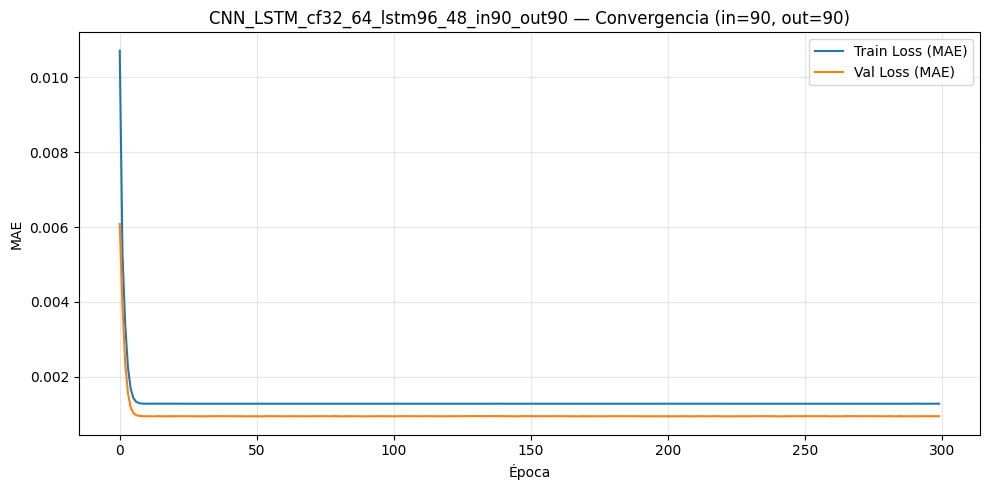

Modelo guardado en: models/CNN_LSTM_cf32_64_lstm96_48_in90_out90.keras


In [28]:
# ============================================================================
# ▶▶▶ CONFIGURACIÓN — CAMBIA AQUÍ LOS PARÁMETROS ◀◀◀
# ============================================================================

# --- Ventanas ---
INPUT_WINDOW  = 90
OUTPUT_WINDOW = 90
# --- Bloque convolucional ---
FILTERS_1     = 32          # Filtros primera Conv1D
KERNEL_SIZE_1 = 5           # Kernel primera Conv1D
FILTERS_2     = 64          # Filtros segunda Conv1D (0 para desactivar)
KERNEL_SIZE_2 = 3           # Kernel segunda Conv1D
PADDING       = 'same'      # Siempre 'same' para mantener resolución temporal
SPATIAL_DROP  = 0.1         # SpatialDropout1D tras cada conv (0 para desactivar)
USE_BATCHNORM = True        # BatchNormalization tras cada conv
L2_REG        = 0.0001      # Regularización L2 en capas conv (0 para desactivar)

# --- Bloque LSTM ---
LSTM_UNITS_1  = 96          # Unidades primera LSTM
LSTM_UNITS_2  = 48           # Unidades segunda LSTM (0 para desactivar)
LSTM_DROPOUT  = 0.1         # Dropout interno de la LSTM (recurrent_dropout)
LSTM_USE_GAP  = False       # True → GlobalAveragePooling sobre salida LSTM
                            # False → usa solo el último hidden state (por defecto)

# --- Bloque denso ---
DENSE_1       = 128          # Neuronas primera capa densa
DENSE_2       = 64          # Neuronas segunda capa densa (0 para desactivar)
DROPOUT_1     = 0.4         # Dropout tras primera densa
DROPOUT_2     = 0.5         # Dropout tras segunda densa

# --- Entrenamiento ---
LEARNING_RATE = 0.001
EPOCHS        = 300
BATCH_SIZE    = 64
MIN_DELTA     = 1e-5
VAL_SPLIT     = 0.1

# --- Nombre del modelo ---
MODEL_NAME = (
    f"CNN_LSTM"
    f"_cf{FILTERS_1}{'_'+str(FILTERS_2) if FILTERS_2 else ''}"
    f"_lstm{LSTM_UNITS_1}{'_'+str(LSTM_UNITS_2) if LSTM_UNITS_2 else ''}"
    f"_in{INPUT_WINDOW}_out{OUTPUT_WINDOW}"
)


# ============================================================================
# CONSTRUCCIÓN DEL MODELO
# ============================================================================

def build_cnn_lstm(input_window, n_features=23):

    reg = l2(L2_REG) if L2_REG > 0 else None

    inp = Input(shape=(input_window, n_features))
    x = inp

    # ── Bloque convolucional ──
    x = Conv1D(FILTERS_1, kernel_size=KERNEL_SIZE_1, padding=PADDING,
               activation='relu', kernel_regularizer=reg)(x)
    if USE_BATCHNORM:
        x = BatchNormalization()(x)
    if SPATIAL_DROP > 0:
        x = SpatialDropout1D(SPATIAL_DROP)(x)

    if FILTERS_2 > 0:
        x = Conv1D(FILTERS_2, kernel_size=KERNEL_SIZE_2, padding=PADDING,
                   activation='relu', kernel_regularizer=reg)(x)
        if USE_BATCHNORM:
            x = BatchNormalization()(x)
        if SPATIAL_DROP > 0:
            x = SpatialDropout1D(SPATIAL_DROP)(x)

    # En este punto: shape = (input_window, FILTERS_2 o FILTERS_1)
    # Es una secuencia temporal de features convolucionales → ideal para LSTM

    # ── Bloque LSTM ──
    return_sequences = (LSTM_UNITS_2 > 0) or LSTM_USE_GAP
    x = LSTM(
        LSTM_UNITS_1,
        return_sequences=return_sequences,
        dropout=LSTM_DROPOUT,
        recurrent_dropout=LSTM_DROPOUT
    )(x)

    if LSTM_UNITS_2 > 0:
        x = LSTM(
            LSTM_UNITS_2,
            return_sequences=LSTM_USE_GAP,
            dropout=LSTM_DROPOUT,
            recurrent_dropout=LSTM_DROPOUT
        )(x)

    if LSTM_USE_GAP:
        x = GlobalAveragePooling1D()(x)

    # ── Bloque denso ──
    x = Dense(DENSE_1, activation='relu')(x)
    if DROPOUT_1 > 0:
        x = Dropout(DROPOUT_1)(x)

    if DENSE_2 > 0:
        x = Dense(DENSE_2, activation='relu')(x)
        if DROPOUT_2 > 0:
            x = Dropout(DROPOUT_2)(x)

    # ── Salida ──
    out = Dense(n_features)(x)

    model = Model(inputs=inp, outputs=out)
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='mae'
    )
    return model


# ============================================================================
# CARGA DE DATOS
# ============================================================================

print("Cargando datos...")
returns = load_data()

X_train, X_test, y_train, y_test = get_train_test(returns, INPUT_WINDOW, OUTPUT_WINDOW)

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}   y_test:  {y_test.shape}")

# Validación temporal (último 10% del train, sin shuffle)
split_idx = int(len(X_train) * (1 - VAL_SPLIT))
X_tr,  y_tr  = X_train[:split_idx], y_train[:split_idx]
X_val, y_val = X_train[split_idx:], y_train[split_idx:]

print(f"Train:   {X_tr.shape}  Val: {X_val.shape}")


# ============================================================================
# CONSTRUCCIÓN E INSPECCIÓN
# ============================================================================

model = build_cnn_lstm(INPUT_WINDOW, n_features=X_train.shape[2])
n_params = count_parameters(model)

print(f"\n{'='*60}")
print(f"  Modelo: {MODEL_NAME}")
print(f"  Parámetros: {n_params:,}")
print(f"{'='*60}")
model.summary()


# ============================================================================
# ENTRENAMIENTO
# ============================================================================


history = model.fit(
    X_tr, y_tr,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),   # validación temporal, sin shuffle
    shuffle=True,                      # shuffle dentro del train está ok
    verbose=1
)

print(f"\nEntrenamiento detenido en la época {len(history.history['loss'])}")


# ============================================================================
# EVALUACIÓN
# ============================================================================

y_pred_train = model.predict(X_train, verbose=0)
y_pred_test  = model.predict(X_test, verbose=0)
y_pred_val   = model.predict(X_val, verbose=0)

mae_train = compute_mae(y_train, y_pred_train)
mae_val   = compute_mae(y_val, y_pred_val)
mae_test  = compute_mae(y_test, y_pred_test)

# Baseline: predecir cero
mae_zero = np.mean(np.abs(y_test))

print(f"\n{'='*60}")
print(f"  Resultados {MODEL_NAME}:")
print(f"    MAE Train:    {mae_train:.6f}")
print(f"    MAE Val:      {mae_val:.6f}")
print(f"    MAE Test:     {mae_test:.6f}")
print(f"    MAE Zero:     {mae_zero:.6f}  (baseline: predecir 0)")
print(f"    Mejora vs 0:  {(mae_zero - mae_test) / mae_zero * 100:.2f}%")
print(f"{'='*60}")

# Comprobar si el modelo predice algo o está "muerto"
y_pred_std = np.std(y_pred_test)
print(f"\n  Diagnóstico:")
print(f"    Std predicciones test: {y_pred_std:.6f}")
if y_pred_std < 1e-4:
    print("    ⚠️  Las predicciones tienen varianza ~0: el modelo predice constante.")
    print("    → Revisa el planteamiento (loss, features, target).")
else:
    print("    ✓  Las predicciones tienen varianza razonable.")


# ============================================================================
# GUARDAR RESULTADOS
# ============================================================================

save_results(
    model_name=MODEL_NAME,
    model_type='cnn_lstm',
    input_window=INPUT_WINDOW,
    output_window=OUTPUT_WINDOW,
    mae_train=mae_train,
    mae_test=mae_test,
    n_params=n_params,
    mae_val=mae_val
)

plot_training_curves(history, MODEL_NAME, INPUT_WINDOW, OUTPUT_WINDOW, save=True)

model_path = os.path.join(MODELS_DIR, f"{MODEL_NAME}.keras")
model.save(model_path)
print(f"Modelo guardado en: {model_path}")

Cargando datos...


[*********************100%***********************]  23 of 23 completed


Datos cargados: 16191 días, 23 activos
Rango: 1962-01-03 → 2026-05-04
Ventana entrada=90, salida=30
  X_train: (14464, 90, 23) | y_train: (14464, 23)
  X_test:  (1608, 90, 23)  | y_test:  (1608, 23)
X_train: (14464, 90, 23)  y_train: (14464, 23)
X_test:  (1608, 90, 23)   y_test:  (1608, 23)
Train:   (13017, 90, 23)  Val: (1447, 90, 23)

  Modelo: CNN_LSTM_cf32_64_lstm96_48_in90_out30
  Parámetros: 115,799


Model: "functional_28"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_28 (InputLayer)     │ (None, 90, 23)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_46 (Conv1D)              │ (None, 90, 32)         │         3,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_46          │ (None, 90, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_29            │ (None, 90, 32)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_47 (Conv1D)              │ (None, 90, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_47          │ (None, 90, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_30            │ (None, 90, 64)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_29 (LSTM)                  │ (None, 90, 96)         │        61,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_30 (LSTM)                  │ (None, 48)             │        27,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_80 (Dense)                │ (None, 128)            │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_46 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_81 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_47 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_82 (Dense)                │ (None, 23)             │         1,495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 115,991 (453.09 KB)

 Trainable params: 115,799 (452.34 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/300
204/204 ━━━━━━━━━━━━━━━━━━━━ 20s 72ms/step - loss: 0.0113 - val_loss: 0.0068
Epoch 2/300
204/204 ━━━━━━━━━━━━━━━━━━━━ 14s 69ms/step - loss: 0.0061 - val_loss: 0.0046
Epoch 3/300
204/204 ━━━━━━━━━━━━━━━━━━━━ 14s 70ms/step - loss: 0.0042 - val_loss: 0.0031
Epoch 4/300
204/204 ━━━━━━━━━━━━━━━━━━━━ 14s 69ms/step - loss: 0.0031 - val_loss: 0.0023
Epoch 5/300
204/204 ━━━━━━━━━━━━━━━━━━━━ 14s 70ms/step - loss: 0.0026 - val_loss: 0.0020
Epoch 6/300
204/204 ━━━━━━━━━━━━━━━━━━━━ 14s 68ms/step - loss: 0.0024 - val_loss: 0.0018
Epoch 7/300
204/204 ━━━━━━━━━━━━━━━━━━━━ 15s 72ms/step - loss: 0.0023 - val_loss: 0.0018
Epoch 8/300
204/204 ━━━━━━━━━━━━━━━━━━━━ 14s 69ms/step - loss: 0.0022 - val_loss: 0.0018
Epoch 9/300
204/204 ━━━━━━━━━━━━━━━━━━━━ 15s 72ms/step - loss: 0.0022 - val_loss: 0.0018
Epoch 10/300
204/204 ━━━━━━━━━━━━━━━━━━━━ 14s 69ms/step - loss: 0.0022 - val_loss: 0.0018
Epoch 11/300
204/204 ━━━━━━━━━━━━━━━━━━━━ 15s 71ms/step - loss: 0.0022 - val_loss: 0.0017
Epoch 12/300
204/20

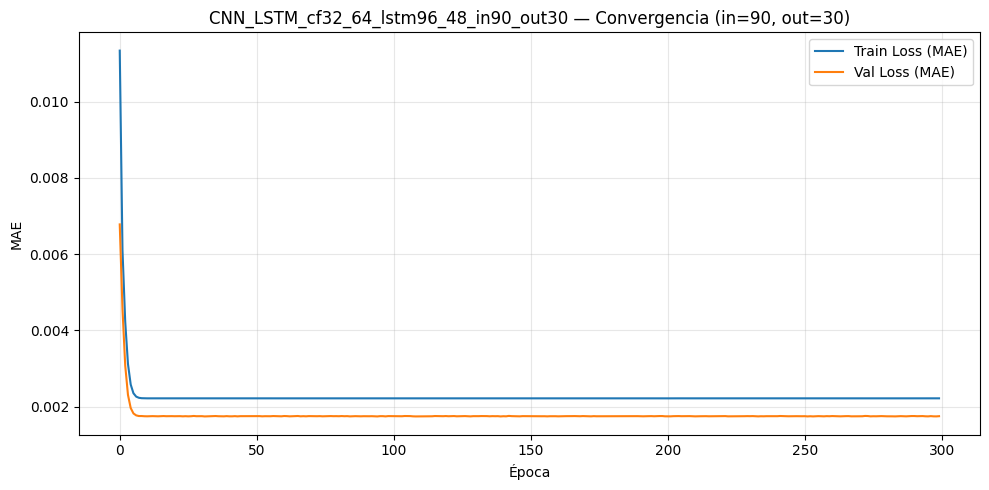

Modelo guardado en: models/CNN_LSTM_cf32_64_lstm96_48_in90_out30.keras


In [29]:
# ============================================================================
# ▶▶▶ CONFIGURACIÓN — CAMBIA AQUÍ LOS PARÁMETROS ◀◀◀
# ============================================================================

# --- Ventanas ---
INPUT_WINDOW  = 90
OUTPUT_WINDOW = 30
# --- Bloque convolucional ---
FILTERS_1     = 32          # Filtros primera Conv1D
KERNEL_SIZE_1 = 5           # Kernel primera Conv1D
FILTERS_2     = 64          # Filtros segunda Conv1D (0 para desactivar)
KERNEL_SIZE_2 = 3           # Kernel segunda Conv1D
PADDING       = 'same'      # Siempre 'same' para mantener resolución temporal
SPATIAL_DROP  = 0.1         # SpatialDropout1D tras cada conv (0 para desactivar)
USE_BATCHNORM = True        # BatchNormalization tras cada conv
L2_REG        = 0.0001      # Regularización L2 en capas conv (0 para desactivar)

# --- Bloque LSTM ---
LSTM_UNITS_1  = 96          # Unidades primera LSTM
LSTM_UNITS_2  = 48           # Unidades segunda LSTM (0 para desactivar)
LSTM_DROPOUT  = 0.1         # Dropout interno de la LSTM (recurrent_dropout)
LSTM_USE_GAP  = False       # True → GlobalAveragePooling sobre salida LSTM
                            # False → usa solo el último hidden state (por defecto)

# --- Bloque denso ---
DENSE_1       = 128          # Neuronas primera capa densa
DENSE_2       = 64          # Neuronas segunda capa densa (0 para desactivar)
DROPOUT_1     = 0.4         # Dropout tras primera densa
DROPOUT_2     = 0.5         # Dropout tras segunda densa

# --- Entrenamiento ---
LEARNING_RATE = 0.001
EPOCHS        = 300
BATCH_SIZE    = 64
MIN_DELTA     = 1e-5
VAL_SPLIT     = 0.1

# --- Nombre del modelo ---
MODEL_NAME = (
    f"CNN_LSTM"
    f"_cf{FILTERS_1}{'_'+str(FILTERS_2) if FILTERS_2 else ''}"
    f"_lstm{LSTM_UNITS_1}{'_'+str(LSTM_UNITS_2) if LSTM_UNITS_2 else ''}"
    f"_in{INPUT_WINDOW}_out{OUTPUT_WINDOW}"
)


# ============================================================================
# CONSTRUCCIÓN DEL MODELO
# ============================================================================

def build_cnn_lstm(input_window, n_features=23):

    reg = l2(L2_REG) if L2_REG > 0 else None

    inp = Input(shape=(input_window, n_features))
    x = inp

    # ── Bloque convolucional ──
    x = Conv1D(FILTERS_1, kernel_size=KERNEL_SIZE_1, padding=PADDING,
               activation='relu', kernel_regularizer=reg)(x)
    if USE_BATCHNORM:
        x = BatchNormalization()(x)
    if SPATIAL_DROP > 0:
        x = SpatialDropout1D(SPATIAL_DROP)(x)

    if FILTERS_2 > 0:
        x = Conv1D(FILTERS_2, kernel_size=KERNEL_SIZE_2, padding=PADDING,
                   activation='relu', kernel_regularizer=reg)(x)
        if USE_BATCHNORM:
            x = BatchNormalization()(x)
        if SPATIAL_DROP > 0:
            x = SpatialDropout1D(SPATIAL_DROP)(x)

    # En este punto: shape = (input_window, FILTERS_2 o FILTERS_1)
    # Es una secuencia temporal de features convolucionales → ideal para LSTM

    # ── Bloque LSTM ──
    return_sequences = (LSTM_UNITS_2 > 0) or LSTM_USE_GAP
    x = LSTM(
        LSTM_UNITS_1,
        return_sequences=return_sequences,
        dropout=LSTM_DROPOUT,
        recurrent_dropout=LSTM_DROPOUT
    )(x)

    if LSTM_UNITS_2 > 0:
        x = LSTM(
            LSTM_UNITS_2,
            return_sequences=LSTM_USE_GAP,
            dropout=LSTM_DROPOUT,
            recurrent_dropout=LSTM_DROPOUT
        )(x)

    if LSTM_USE_GAP:
        x = GlobalAveragePooling1D()(x)

    # ── Bloque denso ──
    x = Dense(DENSE_1, activation='relu')(x)
    if DROPOUT_1 > 0:
        x = Dropout(DROPOUT_1)(x)

    if DENSE_2 > 0:
        x = Dense(DENSE_2, activation='relu')(x)
        if DROPOUT_2 > 0:
            x = Dropout(DROPOUT_2)(x)

    # ── Salida ──
    out = Dense(n_features)(x)

    model = Model(inputs=inp, outputs=out)
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='mae'
    )
    return model


# ============================================================================
# CARGA DE DATOS
# ============================================================================

print("Cargando datos...")
returns = load_data()

X_train, X_test, y_train, y_test = get_train_test(returns, INPUT_WINDOW, OUTPUT_WINDOW)

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}   y_test:  {y_test.shape}")

# Validación temporal (último 10% del train, sin shuffle)
split_idx = int(len(X_train) * (1 - VAL_SPLIT))
X_tr,  y_tr  = X_train[:split_idx], y_train[:split_idx]
X_val, y_val = X_train[split_idx:], y_train[split_idx:]

print(f"Train:   {X_tr.shape}  Val: {X_val.shape}")


# ============================================================================
# CONSTRUCCIÓN E INSPECCIÓN
# ============================================================================

model = build_cnn_lstm(INPUT_WINDOW, n_features=X_train.shape[2])
n_params = count_parameters(model)

print(f"\n{'='*60}")
print(f"  Modelo: {MODEL_NAME}")
print(f"  Parámetros: {n_params:,}")
print(f"{'='*60}")
model.summary()


# ============================================================================
# ENTRENAMIENTO
# ============================================================================


history = model.fit(
    X_tr, y_tr,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),   # validación temporal, sin shuffle
    shuffle=True,                      # shuffle dentro del train está ok
    verbose=1
)

print(f"\nEntrenamiento detenido en la época {len(history.history['loss'])}")


# ============================================================================
# EVALUACIÓN
# ============================================================================

y_pred_train = model.predict(X_train, verbose=0)
y_pred_test  = model.predict(X_test, verbose=0)
y_pred_val   = model.predict(X_val, verbose=0)

mae_train = compute_mae(y_train, y_pred_train)
mae_val   = compute_mae(y_val, y_pred_val)
mae_test  = compute_mae(y_test, y_pred_test)

# Baseline: predecir cero
mae_zero = np.mean(np.abs(y_test))

print(f"\n{'='*60}")
print(f"  Resultados {MODEL_NAME}:")
print(f"    MAE Train:    {mae_train:.6f}")
print(f"    MAE Val:      {mae_val:.6f}")
print(f"    MAE Test:     {mae_test:.6f}")
print(f"    MAE Zero:     {mae_zero:.6f}  (baseline: predecir 0)")
print(f"    Mejora vs 0:  {(mae_zero - mae_test) / mae_zero * 100:.2f}%")
print(f"{'='*60}")

# Comprobar si el modelo predice algo o está "muerto"
y_pred_std = np.std(y_pred_test)
print(f"\n  Diagnóstico:")
print(f"    Std predicciones test: {y_pred_std:.6f}")
if y_pred_std < 1e-4:
    print("    ⚠️  Las predicciones tienen varianza ~0: el modelo predice constante.")
    print("    → Revisa el planteamiento (loss, features, target).")
else:
    print("    ✓  Las predicciones tienen varianza razonable.")


# ============================================================================
# GUARDAR RESULTADOS
# ============================================================================

save_results(
    model_name=MODEL_NAME,
    model_type='cnn_lstm',
    input_window=INPUT_WINDOW,
    output_window=OUTPUT_WINDOW,
    mae_train=mae_train,
    mae_test=mae_test,
    n_params=n_params,
    mae_val=mae_val
)

plot_training_curves(history, MODEL_NAME, INPUT_WINDOW, OUTPUT_WINDOW, save=True)

model_path = os.path.join(MODELS_DIR, f"{MODEL_NAME}.keras")
model.save(model_path)
print(f"Modelo guardado en: {model_path}")

Cargando datos...


[*********************100%***********************]  23 of 23 completed


Datos cargados: 16191 días, 23 activos
Rango: 1962-01-03 → 2026-05-04
Ventana entrada=90, salida=5
  X_train: (14487, 90, 23) | y_train: (14487, 23)
  X_test:  (1610, 90, 23)  | y_test:  (1610, 23)
X_train: (14487, 90, 23)  y_train: (14487, 23)
X_test:  (1610, 90, 23)   y_test:  (1610, 23)
Train:   (13038, 90, 23)  Val: (1449, 90, 23)

  Modelo: CNN_LSTM_cf32_64_lstm80_in90_out5
  Parámetros: 64,535


Model: "functional_29"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_29 (InputLayer)     │ (None, 90, 23)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_48 (Conv1D)              │ (None, 90, 32)         │         3,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_48          │ (None, 90, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_31            │ (None, 90, 32)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_49 (Conv1D)              │ (None, 90, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_49          │ (None, 90, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_32            │ (None, 90, 64)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_31 (LSTM)                  │ (None, 80)             │        46,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_83 (Dense)                │ (None, 64)             │         5,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_48 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_84 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_49 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_85 (Dense)                │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,727 (252.84 KB)

 Trainable params: 64,535 (252.09 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/300
204/204 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - loss: 0.0192 - val_loss: 0.0102
Epoch 2/300
204/204 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - loss: 0.0110 - val_loss: 0.0089
Epoch 3/300
204/204 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - loss: 0.0096 - val_loss: 0.0077
Epoch 4/300
204/204 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - loss: 0.0084 - val_loss: 0.0066
Epoch 5/300
204/204 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - loss: 0.0074 - val_loss: 0.0057
Epoch 6/300
204/204 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - loss: 0.0067 - val_loss: 0.0052
Epoch 7/300
204/204 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - loss: 0.0062 - val_loss: 0.0048
Epoch 8/300
204/204 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - loss: 0.0059 - val_loss: 0.0045
Epoch 9/300
204/204 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - loss: 0.0057 - val_loss: 0.0044
Epoch 10/300
204/204 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - loss: 0.0056 - val_loss: 0.0043
Epoch 11/300
204/204 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - loss: 0.0056 - val_loss: 0.0042
Epoch 12/300
204/204 ━━━━━━━━

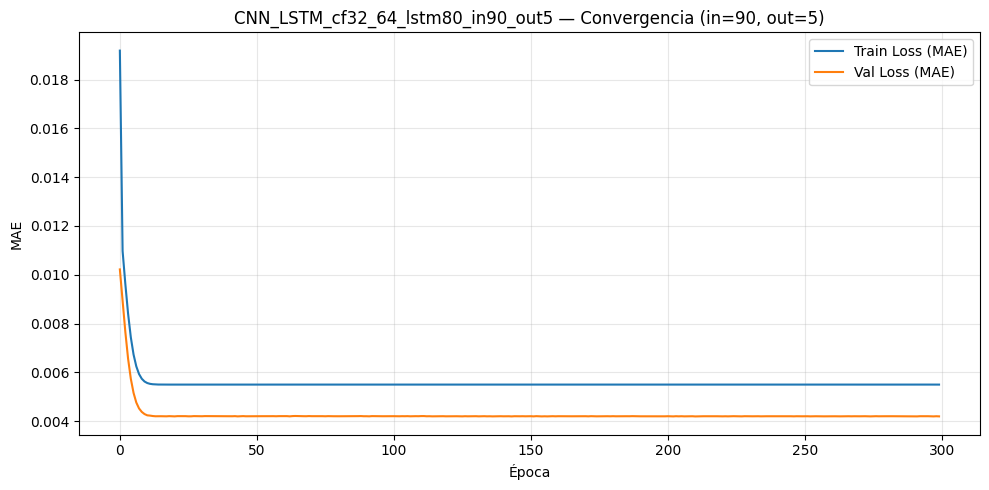

Modelo guardado en: models/CNN_LSTM_cf32_64_lstm80_in90_out5.keras


In [30]:
# ============================================================================
# ▶▶▶ CONFIGURACIÓN — CAMBIA AQUÍ LOS PARÁMETROS ◀◀◀
# ============================================================================

# --- Ventanas ---
INPUT_WINDOW  = 90
OUTPUT_WINDOW = 5
# --- Bloque convolucional ---
FILTERS_1     = 32          # Filtros primera Conv1D
KERNEL_SIZE_1 = 5           # Kernel primera Conv1D
FILTERS_2     = 64          # Filtros segunda Conv1D (0 para desactivar)
KERNEL_SIZE_2 = 3           # Kernel segunda Conv1D
PADDING       = 'same'      # Siempre 'same' para mantener resolución temporal
SPATIAL_DROP  = 0.1         # SpatialDropout1D tras cada conv (0 para desactivar)
USE_BATCHNORM = True        # BatchNormalization tras cada conv
L2_REG        = 0.0001      # Regularización L2 en capas conv (0 para desactivar)

# --- Bloque LSTM ---
LSTM_UNITS_1  = 80          # Unidades primera LSTM
LSTM_UNITS_2  = 0           # Unidades segunda LSTM (0 para desactivar)
LSTM_DROPOUT  = 0.1         # Dropout interno de la LSTM (recurrent_dropout)
LSTM_USE_GAP  = False       # True → GlobalAveragePooling sobre salida LSTM
                            # False → usa solo el último hidden state (por defecto)

# --- Bloque denso ---
DENSE_1       = 64          # Neuronas primera capa densa
DENSE_2       = 32          # Neuronas segunda capa densa (0 para desactivar)
DROPOUT_1     = 0.3         # Dropout tras primera densa
DROPOUT_2     = 0.4         # Dropout tras segunda densa

# --- Entrenamiento ---
LEARNING_RATE = 0.001
EPOCHS        = 300
BATCH_SIZE    = 64
MIN_DELTA     = 1e-5
VAL_SPLIT     = 0.1

# --- Nombre del modelo ---
MODEL_NAME = (
    f"CNN_LSTM"
    f"_cf{FILTERS_1}{'_'+str(FILTERS_2) if FILTERS_2 else ''}"
    f"_lstm{LSTM_UNITS_1}{'_'+str(LSTM_UNITS_2) if LSTM_UNITS_2 else ''}"
    f"_in{INPUT_WINDOW}_out{OUTPUT_WINDOW}"
)


# ============================================================================
# CONSTRUCCIÓN DEL MODELO
# ============================================================================

def build_cnn_lstm(input_window, n_features=23):

    reg = l2(L2_REG) if L2_REG > 0 else None

    inp = Input(shape=(input_window, n_features))
    x = inp

    # ── Bloque convolucional ──
    x = Conv1D(FILTERS_1, kernel_size=KERNEL_SIZE_1, padding=PADDING,
               activation='relu', kernel_regularizer=reg)(x)
    if USE_BATCHNORM:
        x = BatchNormalization()(x)
    if SPATIAL_DROP > 0:
        x = SpatialDropout1D(SPATIAL_DROP)(x)

    if FILTERS_2 > 0:
        x = Conv1D(FILTERS_2, kernel_size=KERNEL_SIZE_2, padding=PADDING,
                   activation='relu', kernel_regularizer=reg)(x)
        if USE_BATCHNORM:
            x = BatchNormalization()(x)
        if SPATIAL_DROP > 0:
            x = SpatialDropout1D(SPATIAL_DROP)(x)

    # En este punto: shape = (input_window, FILTERS_2 o FILTERS_1)
    # Es una secuencia temporal de features convolucionales → ideal para LSTM

    # ── Bloque LSTM ──
    return_sequences = (LSTM_UNITS_2 > 0) or LSTM_USE_GAP
    x = LSTM(
        LSTM_UNITS_1,
        return_sequences=return_sequences,
        dropout=LSTM_DROPOUT,
        recurrent_dropout=LSTM_DROPOUT
    )(x)

    if LSTM_UNITS_2 > 0:
        x = LSTM(
            LSTM_UNITS_2,
            return_sequences=LSTM_USE_GAP,
            dropout=LSTM_DROPOUT,
            recurrent_dropout=LSTM_DROPOUT
        )(x)

    if LSTM_USE_GAP:
        x = GlobalAveragePooling1D()(x)

    # ── Bloque denso ──
    x = Dense(DENSE_1, activation='relu')(x)
    if DROPOUT_1 > 0:
        x = Dropout(DROPOUT_1)(x)

    if DENSE_2 > 0:
        x = Dense(DENSE_2, activation='relu')(x)
        if DROPOUT_2 > 0:
            x = Dropout(DROPOUT_2)(x)

    # ── Salida ──
    out = Dense(n_features)(x)

    model = Model(inputs=inp, outputs=out)
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='mae'
    )
    return model


# ============================================================================
# CARGA DE DATOS
# ============================================================================

print("Cargando datos...")
returns = load_data()

X_train, X_test, y_train, y_test = get_train_test(returns, INPUT_WINDOW, OUTPUT_WINDOW)

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}   y_test:  {y_test.shape}")

# Validación temporal (último 10% del train, sin shuffle)
split_idx = int(len(X_train) * (1 - VAL_SPLIT))
X_tr,  y_tr  = X_train[:split_idx], y_train[:split_idx]
X_val, y_val = X_train[split_idx:], y_train[split_idx:]

print(f"Train:   {X_tr.shape}  Val: {X_val.shape}")


# ============================================================================
# CONSTRUCCIÓN E INSPECCIÓN
# ============================================================================

model = build_cnn_lstm(INPUT_WINDOW, n_features=X_train.shape[2])
n_params = count_parameters(model)

print(f"\n{'='*60}")
print(f"  Modelo: {MODEL_NAME}")
print(f"  Parámetros: {n_params:,}")
print(f"{'='*60}")
model.summary()


# ============================================================================
# ENTRENAMIENTO
# ============================================================================


history = model.fit(
    X_tr, y_tr,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),   # validación temporal, sin shuffle
    shuffle=True,                      # shuffle dentro del train está ok
    verbose=1
)

print(f"\nEntrenamiento detenido en la época {len(history.history['loss'])}")


# ============================================================================
# EVALUACIÓN
# ============================================================================

y_pred_train = model.predict(X_train, verbose=0)
y_pred_test  = model.predict(X_test, verbose=0)
y_pred_val   = model.predict(X_val, verbose=0)

mae_train = compute_mae(y_train, y_pred_train)
mae_val   = compute_mae(y_val, y_pred_val)
mae_test  = compute_mae(y_test, y_pred_test)

# Baseline: predecir cero
mae_zero = np.mean(np.abs(y_test))

print(f"\n{'='*60}")
print(f"  Resultados {MODEL_NAME}:")
print(f"    MAE Train:    {mae_train:.6f}")
print(f"    MAE Val:      {mae_val:.6f}")
print(f"    MAE Test:     {mae_test:.6f}")
print(f"    MAE Zero:     {mae_zero:.6f}  (baseline: predecir 0)")
print(f"    Mejora vs 0:  {(mae_zero - mae_test) / mae_zero * 100:.2f}%")
print(f"{'='*60}")

# Comprobar si el modelo predice algo o está "muerto"
y_pred_std = np.std(y_pred_test)
print(f"\n  Diagnóstico:")
print(f"    Std predicciones test: {y_pred_std:.6f}")
if y_pred_std < 1e-4:
    print("    ⚠️  Las predicciones tienen varianza ~0: el modelo predice constante.")
    print("    → Revisa el planteamiento (loss, features, target).")
else:
    print("    ✓  Las predicciones tienen varianza razonable.")


# ============================================================================
# GUARDAR RESULTADOS
# ============================================================================

save_results(
    model_name=MODEL_NAME,
    model_type='cnn_lstm',
    input_window=INPUT_WINDOW,
    output_window=OUTPUT_WINDOW,
    mae_train=mae_train,
    mae_test=mae_test,
    n_params=n_params,
    mae_val=mae_val
)

plot_training_curves(history, MODEL_NAME, INPUT_WINDOW, OUTPUT_WINDOW, save=True)

model_path = os.path.join(MODELS_DIR, f"{MODEL_NAME}.keras")
model.save(model_path)
print(f"Modelo guardado en: {model_path}")

Cargando datos...


[*********************100%***********************]  23 of 23 completed


Datos cargados: 16191 días, 23 activos
Rango: 1962-01-03 → 2026-05-04
Ventana entrada=90, salida=1
  X_train: (14490, 90, 23) | y_train: (14490, 23)
  X_test:  (1611, 90, 23)  | y_test:  (1611, 23)
X_train: (14490, 90, 23)  y_train: (14490, 23)
X_test:  (1611, 90, 23)   y_test:  (1611, 23)
Train:   (13041, 90, 23)  Val: (1449, 90, 23)

  Modelo: CNN_LSTM_cf32_64_lstm64_in90_out1
  Parámetros: 45,975


Model: "functional_30"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_30 (InputLayer)     │ (None, 90, 23)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_50 (Conv1D)              │ (None, 90, 32)         │         3,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_50          │ (None, 90, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_33            │ (None, 90, 32)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_51 (Conv1D)              │ (None, 90, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_51          │ (None, 90, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_34            │ (None, 90, 64)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_32 (LSTM)                  │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_86 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_50 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_87 (Dense)                │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,167 (180.34 KB)

 Trainable params: 45,975 (179.59 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/300
204/204 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - loss: 0.0259 - val_loss: 0.0152
Epoch 2/300
204/204 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - loss: 0.0174 - val_loss: 0.0139
Epoch 3/300
204/204 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - loss: 0.0160 - val_loss: 0.0126
Epoch 4/300
204/204 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - loss: 0.0148 - val_loss: 0.0115
Epoch 5/300
204/204 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - loss: 0.0139 - val_loss: 0.0107
Epoch 6/300
204/204 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - loss: 0.0132 - val_loss: 0.0101
Epoch 7/300
204/204 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - loss: 0.0127 - val_loss: 0.0097
Epoch 8/300
204/204 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - loss: 0.0123 - val_loss: 0.0094
Epoch 9/300
204/204 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - loss: 0.0121 - val_loss: 0.0093
Epoch 10/300
204/204 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - loss: 0.0120 - val_loss: 0.0092
Epoch 11/300
204/204 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - loss: 0.0120 - val_loss: 0.0091
Epoch 12/300
204/204 ━━━━━━━━━

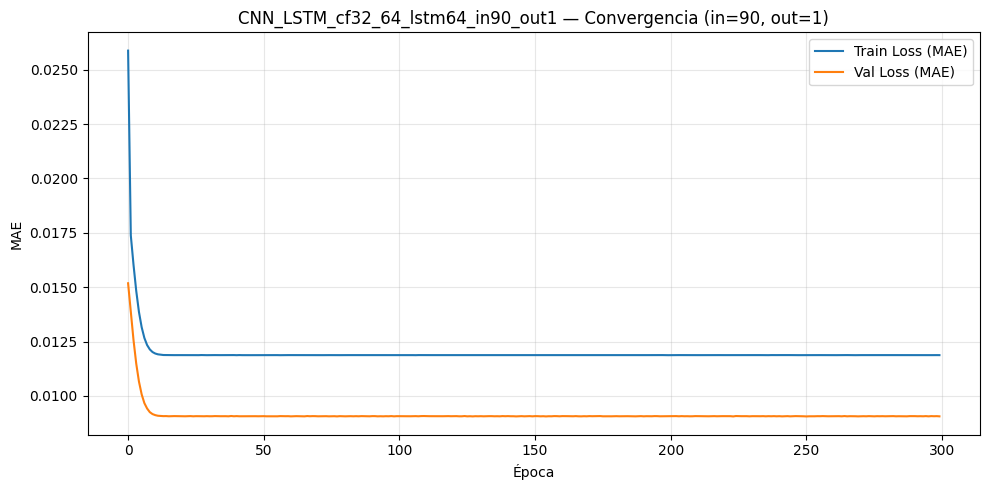

Modelo guardado en: models/CNN_LSTM_cf32_64_lstm64_in90_out1.keras


In [31]:
# ============================================================================
# ▶▶▶ CONFIGURACIÓN — CAMBIA AQUÍ LOS PARÁMETROS ◀◀◀
# ============================================================================

# --- Ventanas ---
INPUT_WINDOW  = 90
OUTPUT_WINDOW = 1
# --- Bloque convolucional ---
FILTERS_1     = 32          # Filtros primera Conv1D
KERNEL_SIZE_1 = 5           # Kernel primera Conv1D
FILTERS_2     = 64          # Filtros segunda Conv1D (0 para desactivar)
KERNEL_SIZE_2 = 3           # Kernel segunda Conv1D
PADDING       = 'same'      # Siempre 'same' para mantener resolución temporal
SPATIAL_DROP  = 0.1         # SpatialDropout1D tras cada conv (0 para desactivar)
USE_BATCHNORM = True        # BatchNormalization tras cada conv
L2_REG        = 0.0001      # Regularización L2 en capas conv (0 para desactivar)

# --- Bloque LSTM ---
LSTM_UNITS_1  = 64          # Unidades primera LSTM
LSTM_UNITS_2  = 0           # Unidades segunda LSTM (0 para desactivar)
LSTM_DROPOUT  = 0.1         # Dropout interno de la LSTM (recurrent_dropout)
LSTM_USE_GAP  = False       # True → GlobalAveragePooling sobre salida LSTM
                            # False → usa solo el último hidden state (por defecto)

# --- Bloque denso ---
DENSE_1       = 32          # Neuronas primera capa densa
DENSE_2       = 0          # Neuronas segunda capa densa (0 para desactivar)
DROPOUT_1     = 0.3         # Dropout tras primera densa
DROPOUT_2     = 0.4         # Dropout tras segunda densa

# --- Entrenamiento ---
LEARNING_RATE = 0.001
EPOCHS        = 300
BATCH_SIZE    = 64
MIN_DELTA     = 1e-5
VAL_SPLIT     = 0.1

# --- Nombre del modelo ---
MODEL_NAME = (
    f"CNN_LSTM"
    f"_cf{FILTERS_1}{'_'+str(FILTERS_2) if FILTERS_2 else ''}"
    f"_lstm{LSTM_UNITS_1}{'_'+str(LSTM_UNITS_2) if LSTM_UNITS_2 else ''}"
    f"_in{INPUT_WINDOW}_out{OUTPUT_WINDOW}"
)


# ============================================================================
# CONSTRUCCIÓN DEL MODELO
# ============================================================================

def build_cnn_lstm(input_window, n_features=23):

    reg = l2(L2_REG) if L2_REG > 0 else None

    inp = Input(shape=(input_window, n_features))
    x = inp

    # ── Bloque convolucional ──
    x = Conv1D(FILTERS_1, kernel_size=KERNEL_SIZE_1, padding=PADDING,
               activation='relu', kernel_regularizer=reg)(x)
    if USE_BATCHNORM:
        x = BatchNormalization()(x)
    if SPATIAL_DROP > 0:
        x = SpatialDropout1D(SPATIAL_DROP)(x)

    if FILTERS_2 > 0:
        x = Conv1D(FILTERS_2, kernel_size=KERNEL_SIZE_2, padding=PADDING,
                   activation='relu', kernel_regularizer=reg)(x)
        if USE_BATCHNORM:
            x = BatchNormalization()(x)
        if SPATIAL_DROP > 0:
            x = SpatialDropout1D(SPATIAL_DROP)(x)

    # En este punto: shape = (input_window, FILTERS_2 o FILTERS_1)
    # Es una secuencia temporal de features convolucionales → ideal para LSTM

    # ── Bloque LSTM ──
    return_sequences = (LSTM_UNITS_2 > 0) or LSTM_USE_GAP
    x = LSTM(
        LSTM_UNITS_1,
        return_sequences=return_sequences,
        dropout=LSTM_DROPOUT,
        recurrent_dropout=LSTM_DROPOUT
    )(x)

    if LSTM_UNITS_2 > 0:
        x = LSTM(
            LSTM_UNITS_2,
            return_sequences=LSTM_USE_GAP,
            dropout=LSTM_DROPOUT,
            recurrent_dropout=LSTM_DROPOUT
        )(x)

    if LSTM_USE_GAP:
        x = GlobalAveragePooling1D()(x)

    # ── Bloque denso ──
    x = Dense(DENSE_1, activation='relu')(x)
    if DROPOUT_1 > 0:
        x = Dropout(DROPOUT_1)(x)

    if DENSE_2 > 0:
        x = Dense(DENSE_2, activation='relu')(x)
        if DROPOUT_2 > 0:
            x = Dropout(DROPOUT_2)(x)

    # ── Salida ──
    out = Dense(n_features)(x)

    model = Model(inputs=inp, outputs=out)
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='mae'
    )
    return model


# ============================================================================
# CARGA DE DATOS
# ============================================================================

print("Cargando datos...")
returns = load_data()

X_train, X_test, y_train, y_test = get_train_test(returns, INPUT_WINDOW, OUTPUT_WINDOW)

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}   y_test:  {y_test.shape}")

# Validación temporal (último 10% del train, sin shuffle)
split_idx = int(len(X_train) * (1 - VAL_SPLIT))
X_tr,  y_tr  = X_train[:split_idx], y_train[:split_idx]
X_val, y_val = X_train[split_idx:], y_train[split_idx:]

print(f"Train:   {X_tr.shape}  Val: {X_val.shape}")


# ============================================================================
# CONSTRUCCIÓN E INSPECCIÓN
# ============================================================================

model = build_cnn_lstm(INPUT_WINDOW, n_features=X_train.shape[2])
n_params = count_parameters(model)

print(f"\n{'='*60}")
print(f"  Modelo: {MODEL_NAME}")
print(f"  Parámetros: {n_params:,}")
print(f"{'='*60}")
model.summary()


# ============================================================================
# ENTRENAMIENTO
# ============================================================================


history = model.fit(
    X_tr, y_tr,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),   # validación temporal, sin shuffle
    shuffle=True,                      # shuffle dentro del train está ok
    verbose=1
)

print(f"\nEntrenamiento detenido en la época {len(history.history['loss'])}")


# ============================================================================
# EVALUACIÓN
# ============================================================================

y_pred_train = model.predict(X_train, verbose=0)
y_pred_test  = model.predict(X_test, verbose=0)
y_pred_val   = model.predict(X_val, verbose=0)

mae_train = compute_mae(y_train, y_pred_train)
mae_val   = compute_mae(y_val, y_pred_val)
mae_test  = compute_mae(y_test, y_pred_test)

# Baseline: predecir cero
mae_zero = np.mean(np.abs(y_test))

print(f"\n{'='*60}")
print(f"  Resultados {MODEL_NAME}:")
print(f"    MAE Train:    {mae_train:.6f}")
print(f"    MAE Val:      {mae_val:.6f}")
print(f"    MAE Test:     {mae_test:.6f}")
print(f"    MAE Zero:     {mae_zero:.6f}  (baseline: predecir 0)")
print(f"    Mejora vs 0:  {(mae_zero - mae_test) / mae_zero * 100:.2f}%")
print(f"{'='*60}")

# Comprobar si el modelo predice algo o está "muerto"
y_pred_std = np.std(y_pred_test)
print(f"\n  Diagnóstico:")
print(f"    Std predicciones test: {y_pred_std:.6f}")
if y_pred_std < 1e-4:
    print("    ⚠️  Las predicciones tienen varianza ~0: el modelo predice constante.")
    print("    → Revisa el planteamiento (loss, features, target).")
else:
    print("    ✓  Las predicciones tienen varianza razonable.")


# ============================================================================
# GUARDAR RESULTADOS
# ============================================================================

save_results(
    model_name=MODEL_NAME,
    model_type='cnn_lstm',
    input_window=INPUT_WINDOW,
    output_window=OUTPUT_WINDOW,
    mae_train=mae_train,
    mae_test=mae_test,
    n_params=n_params,
    mae_val=mae_val
)

plot_training_curves(history, MODEL_NAME, INPUT_WINDOW, OUTPUT_WINDOW, save=True)

model_path = os.path.join(MODELS_DIR, f"{MODEL_NAME}.keras")
model.save(model_path)
print(f"Modelo guardado en: {model_path}")